In [1]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
from peft import LoraConfig, get_peft_model, PeftModel
import torch


device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model_id = "yoakiyama/MSA-Pairformer"


from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA

msa_pairformer = MSAPairformer.from_pretrained(device=device)


/home/mooolab/anaconda3/envs/pairformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 1294.59it/s]


In [2]:
print(msa_pairformer.device)
print(sum(p.numel() for p in msa_pairformer.parameters()) / 1e6, "M parameters")


cuda:1
111.365468 M parameters


In [4]:
# [진단용 셀]
# LoRA 적용 전에 이 셀을 먼저 실행해 보세요.

# 모델의 모듈 중 하나를 직접 출력해봅니다.
print(msa_pairformer.core_stack.layers[0][0].msa_to_values_and_gates[1])

LinearNoBias(in_features=464, out_features=512, bias=False)


In [5]:
# for name, module in msa_pairformer.named_modules():
#     if "to_out" in name:
#         print(name, type(module))


In [6]:
import torch.nn as nn
from peft import LoraConfig, get_peft_model

# 1️⃣ 모든 모듈 이름 출력해서 dropout 있는 애 걸러내기
dropout_names = [name for name, m in msa_pairformer.named_modules() if isinstance(m, nn.Dropout)]
dropout_names_set = set(dropout_names)

# 2️⃣ LoRA 타깃 후보
base_target_modules = [
    "msa_to_values_and_gates.1",
    "pairwise_repr_to_attn.1",
    "to_out.1",
    "lm_head.dense",
]

# 3️⃣ Dropout 이름이 겹치는 경우 자동 제외
safe_targets = []
for t in base_target_modules:
    if not any(t in d for d in dropout_names_set):
        safe_targets.append(t)

print(f" 최종 LoRA 타깃 모듈: {safe_targets}")

# 4️⃣ LoRA 설정 및 적용
lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=safe_targets,
    lora_dropout=0.1,
    bias="none",
)

lora_model = get_peft_model(msa_pairformer, lora_config)
lora_model.print_trainable_parameters()


 최종 LoRA 타깃 모듈: ['msa_to_values_and_gates.1', 'pairwise_repr_to_attn.1', 'lm_head.dense']
trainable params: 1,914,368 || all params: 113,279,836 || trainable%: 1.6899


In [7]:
from peft.tuners.lora import LoraLayer
import torch.nn as nn

def print_lora_injected_layers(model):
    print("\n=== LoRA Injected Layers ===\n")
    
    for name, module in model.named_modules():
        if isinstance(module, LoraLayer):
            print(f"[LoRA Layer] {name}")
            print(module)
            print("-" * 50)


print_lora_injected_layers(lora_model)


=== LoRA Injected Layers ===

[LoRA Layer] base_model.model.core_stack.layers.0.0.msa_to_values_and_gates.1
lora.Linear(
  (base_layer): LinearNoBias(in_features=464, out_features=512, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.1, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=464, out_features=64, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=64, out_features=512, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)
--------------------------------------------------
[LoRA Layer] base_model.model.core_stack.layers.0.0.pairwise_repr_to_attn.1
lora.Linear(
  (base_layer): LinearNoBias(in_features=256, out_features=8, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.1, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=256, out_features=64, bias=False)
  )
  (lora_B): ModuleDict(


In [8]:
# import torch
# import torch.nn.functional as F
# from torch.optim import Adam
# from MSA_Pairformer.dataset import MSA, msa_mlm, aa2tok_d
# from torch.utils.checkpoint import checkpoint

# # 🔹 1. 디바이스 설정
# device = next(lora_model.parameters()).device

# # # 🔹 2. 모델을 bf16으로 변환
# lora_model = lora_model.to(torch.bfloat16)
# lora_model.train()

# # 🔹 3. MSA 데이터 불러오기
# msa_path = "X5L4P3.a3m"
# msa_data = MSA(msa_path, diverse_select_method="none")
# msa_t = msa_data.diverse_tokenized_msa.unsqueeze(0).to(device)

# # 🔹 4. 마스킹 (mutate_pssm=False)
# masked_msa, mlm_indices = msa_mlm(
#     msa_t.cpu(),
#     mask_prob=0.15,
#     mutate_pssm=False
# )
# masked_msa = masked_msa.to(device)

# # 🔹 5. one-hot 인코딩 (bf16)
# msa_onehot = torch.nn.functional.one_hot(masked_msa, num_classes=28).to(torch.bfloat16).to(device)

# # 🔹 6. forward (autocast로 bf16 연산)
# with torch.cuda.amp.autocast(dtype=torch.bfloat16):
#     output = lora_model(msa=msa_onehot)
#     logits = output["logits"]  # (B, 1, L, vocab)

#     # query-only masking
#     mask = (masked_msa[:, 0, :] == aa2tok_d["<mask>"])  # (B, L)
#     labels = msa_t[:, 0, :]  # (B, L)

#     masked_logits = logits[:, 0, :, :][mask]
#     masked_labels = labels[mask]

#     # 🔹 7. CrossEntropy는 fp32로 계산 (정확도 유지용)
#     loss = F.cross_entropy(masked_logits.float(), masked_labels.long())

# print(f"✅ Loss computed successfully (bf16): {loss.item():.4f} | masked tokens: {mask.sum().item()}")


In [9]:
from glob import glob
import random
from MSA_Pairformer.dataset import MSADataset, CollateAFBatch

# -----------------------------
# 0️⃣ Config
# -----------------------------
msa_root = "/mnt/mooo/yoosun/army/MSA_Pairformer/msa_BFVD"
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

max_seq_len = 128
max_depth = 32

# -----------------------------
# [추가] 랜덤 시드 고정 (이 코드가 꼭 필요합니다!)
# -----------------------------
SEED = 42  # 원하는 숫자로 설정 (보통 42를 많이 씀)
random.seed(SEED)
# 만약 numpy나 torch도 쓴다면 같이 고정하는 게 좋습니다.
# np.random.seed(SEED)
# torch.manual_seed(SEED)

# -----------------------------
# 1️⃣ 모든 .a3m 파일 수집
# -----------------------------
all_files = glob(f"{msa_root}/**/*.a3m", recursive=True)
# glob 결과는 운영체제마다 순서가 다를 수 있으므로, 한 번 정렬 후 섞는 게 가장 안전합니다.
all_files.sort() 

print(f"📁 Found total MSA files: {len(all_files)}")

# 랜덤 셔플 (위에서 seed를 고정했으므로 항상 똑같이 섞임)
random.shuffle(all_files)

# -----------------------------
# 2️⃣ Split
# -----------------------------
N = len(all_files)
train_files = all_files[:int(N * train_ratio)]
val_files   = all_files[int(N * train_ratio):int(N * (train_ratio + val_ratio))]
test_files  = all_files[int(N * (train_ratio + val_ratio)):]

print(f"✔ Train: {len(train_files)}")
print(f"✔ Val:   {len(val_files)}")
print(f"✔ Test:  {len(test_files)}")

📁 Found total MSA files: 351242
✔ Train: 280993
✔ Val:   35124
✔ Test:  35125


In [10]:
from torch.utils.data import DataLoader
import torch

# Dataset
train_dataset = MSADataset(
    msa_paths=train_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

val_dataset = MSADataset(
    msa_paths=val_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

test_dataset = MSADataset(
    msa_paths=test_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

# Collate
train_collate = CollateAFBatch(
    max_seq_length=max_seq_len,
    max_seq_depth=max_depth,
    min_seq_depth=4,
    mask_prob=0,
    mutate_pssm=False,
    query_only=True
)

val_collate = CollateAFBatch(
    max_seq_length=max_seq_len,
    max_seq_depth=max_depth,
    min_seq_depth=4,
    mask_prob=0,
    mutate_pssm=False,
    query_only=True
)

# Dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    collate_fn=train_collate,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    collate_fn=val_collate,
    pin_memory=True
)


In [11]:
from MSA_Pairformer.dataset import MSA

msa = MSA("/mnt/mooo/yoosun/army/MSA_Pairformer/msa_BFVD/A0A513PZY6.a3m")
print(len(msa.seq_a))

497


In [12]:
# -----------------------------
# 1️⃣ Dataloader Sanity Check
# -----------------------------
from MSA_Pairformer.dataset import prepare_inputs_bf16
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA, aa2tok_d, prepare_msa_masks
batch = next(iter(train_loader))

print("✔ Batch loaded!")
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"{k:20s} | shape = {tuple(v.shape)} | dtype = {v.dtype}")
    else:
        print(f"{k:20s} | {v}")

# Prepare inputs (bf16)
msa_repr, mask, msa_mask, full_mask, pairwise_mask, molecule_feats = prepare_inputs_bf16(batch, device)

print("\n✔ Prepared inputs:")
print("msa_repr:", msa_repr.shape)
print("mask:", mask.shape)

# forward
with torch.cuda.amp.autocast(dtype=torch.bfloat16):
    out = lora_model(
        msa=msa_repr,
        mask=mask,
        msa_mask=msa_mask,
        full_mask=full_mask,
        pairwise_mask=pairwise_mask,
        # molecule_feats=molecule_feats,
        return_contacts=False,
        query_only=True
    )

print("\n✔ Forward OK")
print("logits:", out["logits"].shape)


✔ Batch loaded!
msas                 | shape = (1, 32, 128) | dtype = torch.int64
msas_onehot          | shape = (1, 32, 128, 28) | dtype = torch.int64
masked_idx           | None
unmasked_msas_onehot | shape = (1, 32, 128, 28) | dtype = torch.int64
molecule_feats       | shape = (1, 128, 5) | dtype = torch.float32
file_path            | ['/mnt/mooo/yoosun/army/MSA_Pairformer/msa_BFVD/A0A5J6VJA4.a3m']
seq_indices          | [[0, 2, 3, 5, 6, 7, 8, 9, 11, 13, 15, 19, 24, 28, 30, 32, 131, 142, 149]]
msa_depths           | shape = (1,) | dtype = torch.int64
mask                 | shape = (1, 128) | dtype = torch.bool
msa_mask             | shape = (1, 32) | dtype = torch.bool
full_mask            | shape = (1, 32, 128) | dtype = torch.bool
pairwise_mask        | shape = (1, 128, 128) | dtype = torch.bool

✔ Prepared inputs:
msa_repr: torch.Size([1, 32, 128, 28])
mask: torch.Size([1, 128])


/tmp/ipykernel_2058157/1006931040.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.bfloat16):



✔ Forward OK
logits: torch.Size([1, 1, 128, 26])


In [13]:
# -----------------------------
# 2️⃣ Optimizer & Scheduler
# -----------------------------
from torch.optim import AdamW

# Cell 13 대체용 코드

from transformers import get_cosine_schedule_with_warmup

# 1. 학습률을 낮춥니다 (1e-4 -> 2e-5)
lr = 5e-4
weight_decay = 0.01 # 일반화 성능을 위해 약간의 weight decay 추가

optimizer = torch.optim.AdamW(lora_model.parameters(), lr=lr, weight_decay=weight_decay)

# 2. Warmup 추가 (초반 100 step 동안은 학습률을 천천히 올림 -> 안정성 확보)
# 전체 step 수는 데이터 양에 따라 다르지만, 여기서는 임의로 5000으로 잡습니다.
max_train_steps = 5000
num_warmup_steps = 500

scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=num_warmup_steps, 
    num_training_steps=max_train_steps
)

print(f"Optimizer & Scheduler Ready (LR: {lr}, Warmup: {num_warmup_steps})")

Optimizer & Scheduler Ready (LR: 0.0005, Warmup: 500)


🛑 단일 배치 오버피팅 테스트 시작...
Iter 10: Loss 0.2702
Iter 20: Loss 0.0650
Iter 30: Loss 0.1102
Iter 40: Loss 0.1718
Iter 50: Loss 0.0129
Iter 60: Loss 0.0020
Iter 70: Loss 0.1645
Iter 80: Loss 0.0338
Iter 90: Loss 0.0084
Iter 100: Loss 0.0040


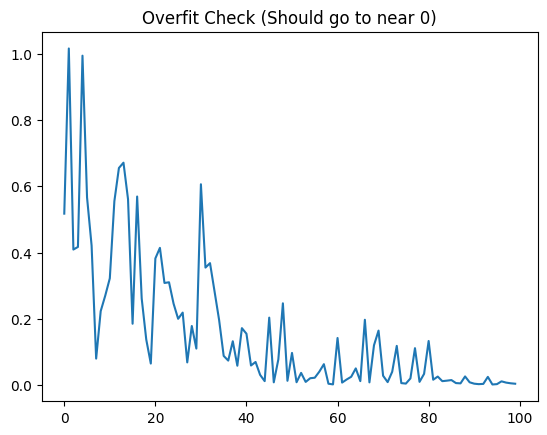

In [14]:
# [디버깅용] 단일 배치 오버피팅 테스트
# 전체 데이터셋 말고, 딱 하나의 배지만 꺼내서 모델이 이걸 외울 수 있는지 봅니다.
import torch
import torch.nn.functional as F
from MSA_Pairformer.dataset import aa2tok_d  # mask 토큰 인덱스 가져오기
# Cell 38 대체용 코드 (Gradient Clipping 추가 & Accumulation 16으로 증가)

ACCUMULATION_STEPS = 16  # 8 -> 16으로 증가 (더 안정적인 학습)
MASK_TOKEN_IDX = aa2tok_d.get("<mask>", 23)

print("🛑 단일 배치 오버피팅 테스트 시작...")

# 1. 데이터 하나 꺼내기
debug_batch = next(iter(train_loader))

# 2. 모델 및 옵티마이저 설정 (학습률을 아주 높게 잡음)
lora_model.train()
debug_optimizer = torch.optim.AdamW(lora_model.parameters(), lr=1e-3) # 강력한 LR

losses = []

# 3. 100번 반복 학습 (같은 데이터로)
for i in range(100):
    # ---- train_step 로직 복사 ----
    msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(debug_batch, device)
    labels = debug_batch["msas"][:, 0, :].to(device).clone()

    # 마스킹 (매번 다르게 하지 말고 고정된 마스크 사용 권장, 여기선 간단히 매번 생성)
    valid_token = (labels >= 0) & (labels < 26)
    rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
    
    # 마스크가 없으면 강제 할당
    if rand_mask.sum() == 0:
        rand_mask[:, 0] = True
        
    masked_positions = rand_mask

    # 입력 마스킹 처리
    msa_repr[:, 0, :, :][masked_positions] = 0.0
    msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

    with torch.amp.autocast("cuda", dtype=torch.bfloat16):
        out = lora_model(
            msa=msa_repr,
            mask=mask,
            msa_mask=msa_mask,
            full_mask=full_mask,
            pairwise_mask=pairwise_mask,
            return_contacts=False,
            query_only=True
        )
        
        logits = out["logits"][:, 0, :, :]
        pred = logits[masked_positions]
        true = labels[masked_positions]
        
        loss = F.cross_entropy(pred.float(), true.long())

    # Backward
    debug_optimizer.zero_grad()
    loss.backward()
    debug_optimizer.step()
    
    losses.append(loss.item())
    
    if (i+1) % 10 == 0:
        print(f"Iter {i+1}: Loss {loss.item():.4f}")

# 결과 시각화
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title("Overfit Check (Should go to near 0)")
plt.show()

In [16]:
# [수정된 train_step 및 val_step]
# 이 셀을 기존 함수 정의 대신 실행하세요.

import torch
import torch.nn.functional as F
from MSA_Pairformer.dataset import aa2tok_d  # mask 토큰 인덱스 가져오기
# Cell 38 대체용 코드 (Gradient Clipping 추가 & Accumulation 16으로 증가)

ACCUMULATION_STEPS = 16  # 8 -> 16으로 증가 (더 안정적인 학습)
MASK_TOKEN_IDX = aa2tok_d.get("<mask>", 23)

def train_step(batch, step_idx):
    lora_model.train()

    # 1) Inputs
    msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(batch, device)
    labels = batch["msas"][:, 0, :].to(device).clone()

    # 2) Masking Logic
    valid_token = (labels >= 0) & (labels < 26) 
    rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
    
    if rand_mask.sum() == 0:
        valid_indices = torch.where(valid_token)[1]
        if len(valid_indices) > 0:
            rand_idx = valid_indices[torch.randint(0, len(valid_indices), (1,))]
            rand_mask[:, rand_idx] = True
            
    masked_positions = rand_mask

    # 3) Apply Mask to Input (Leakage 방지)
    msa_repr[:, 0, :, :][masked_positions] = 0.0
    msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

    # 4) Forward
    with torch.amp.autocast("cuda", dtype=torch.bfloat16):
        out = lora_model(
            msa=msa_repr,
            mask=mask,
            msa_mask=msa_mask,
            full_mask=full_mask,
            pairwise_mask=pairwise_mask,
            return_contacts=False,
            query_only=True
        )

        logits = out["logits"][:, 0, :, :]
        pred = logits[masked_positions]
        true = labels[masked_positions]

        valid_label_mask = (true >= 0) & (true < logits.size(-1))
        pred = pred[valid_label_mask]
        true = true[valid_label_mask]

        if true.numel() == 0:
            return 0.0

        loss = F.cross_entropy(pred.float(), true.long())
        loss = loss / ACCUMULATION_STEPS

    # 5) Backward
    loss.backward()

    # 6) Optimizer Step with Gradient Clipping (핵심 추가 사항)
    if (step_idx + 1) % ACCUMULATION_STEPS == 0:
        # 그라디언트가 너무 크면(1.0 초과) 잘라냅니다. 튀는 현상 방지.
        torch.nn.utils.clip_grad_norm_(lora_model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return loss.item() * ACCUMULATION_STEPS
def val_step(batch):
    lora_model.eval()

    with torch.no_grad():
        msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(batch, device)
        labels = batch["msas"][:, 0, :].to(device)

        # Validation에서도 동일하게 마스킹을 해서 '복원 능력'을 평가해야 함
        valid_token = (labels >= 0) & (labels < 26)
        rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
        masked_positions = rand_mask

        # [검증용] 입력 마스킹 적용
        msa_repr[:, 0, :, :][masked_positions] = 0.0
        msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            out = lora_model(
                msa=msa_repr,
                mask=mask,
                msa_mask=msa_mask,
                full_mask=full_mask,
                pairwise_mask=pairwise_mask,
                return_contacts=False,
                query_only=True
            )

        logits = out["logits"][:, 0, :, :]
        
        pred = logits[masked_positions]
        true = labels[masked_positions]
        
        valid_label_mask = (true >= 0) & (true < logits.size(-1))
        pred = pred[valid_label_mask]
        true = true[valid_label_mask]

        if true.numel() == 0:
            return None

        loss = F.cross_entropy(pred.float(), true.long())

    return loss.item()

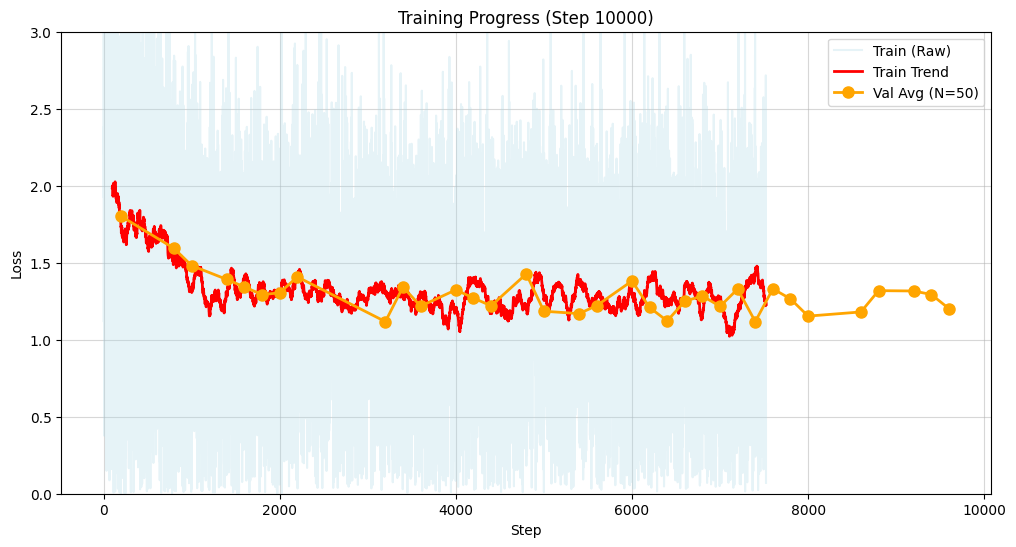

Training Finished.


In [18]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm
import numpy as np

# -----------------------------------------------------------
# [수정됨] 오류 없는 라이브 플롯 함수
# -----------------------------------------------------------
def live_plot(train_loss_list, val_step_list, val_loss_list, current_step):
    clear_output(wait=True)
    plt.figure(figsize=(12, 6))
    
    # Train Loss (흐리게)
    plt.plot(train_loss_list, label='Train (Raw)', color='lightblue', alpha=0.3)
    
    # Train Trend (진하게)
    if len(train_loss_list) > 10:
        # 윈도우 크기를 고정하지 않고 데이터 상황에 맞게 처리
        window_size = 100
        ma = moving_average(train_loss_list, window_size)
        
        # [핵심 수정] X축 범위를 데이터(ma) 길이에 맞춰서 자동으로 생성
        # 데이터가 적어서 원본이 반환되든, 많아서 평균이 반환되든 항상 길이가 맞음
        x_range = range(len(train_loss_list) - len(ma), len(train_loss_list))
        
        plt.plot(x_range, ma, label='Train Trend', color='red', linewidth=2)

    # Val Loss (주황색 점 & 선)
    if len(val_loss_list) > 0:
        plt.plot(val_step_list, val_loss_list, label=f'Val Avg (N={VAL_BATCHES})', 
                 color='orange', marker='o', linewidth=2, markersize=8)

    plt.title(f'Training Progress (Step {current_step})')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.ylim(0, 3.0)
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.show()

# -----------------------------------------------------------
# 학습 루프 재시작
# -----------------------------------------------------------
# (주의: 이전 셀에서 train_losses 등이 초기화되지 않도록 주의하세요.
#  만약 처음부터 다시 하려면 위쪽 변수 초기화 코드도 실행해야 합니다.
#  여기서는 이어서 한다고 가정하고 루프만 다시 돌립니다.)

# 혹시 멈춰서 pbar가 닫혔을 수 있으니 다시 생성
# 이미 진행된 step부터 시작하도록 range 조정
start_step = len(train_losses) # 대략적으로 현재 진행된 곳부터
if start_step >= MAX_STEPS:
    print("이미 학습이 완료되었습니다.")
else:
    print(f"Resuming training from step {start_step}...")
    
    # Iterator를 다시 해당 위치로 이동 (skip)
    train_iter = iter(train_loader)
    for _ in range(start_step):
        next(train_iter, None)
        
    pbar = tqdm(enumerate(train_iter, start=start_step), total=MAX_STEPS, initial=start_step)
    
    for step, batch in pbar:
        if step >= MAX_STEPS: break
        if batch is None: continue

        # 1. TRAIN
        loss = train_step(batch, step)
        if loss != 0.0:
            train_losses.append(loss)

        # 2. VALIDATE (N개 배치 평균)
        avg_val_loss = None
        
        if step % VAL_INTERVAL == 0 and step > 0:
            temp_val_losses = []
            lora_model.eval()
            
            for _ in range(VAL_BATCHES):
                try:
                    v_batch = next(val_iter)
                except StopIteration:
                    val_iter = iter(val_loader)
                    v_batch = next(val_iter)
                
                if v_batch is not None:
                    v_loss = val_step(v_batch)
                    if v_loss is not None:
                        temp_val_losses.append(v_loss)
            
            lora_model.train()
            
            if len(temp_val_losses) > 0:
                avg_val_loss = sum(temp_val_losses) / len(temp_val_losses)
                val_losses.append(avg_val_loss)
                val_steps.append(step)

        # 3. Plot & Log (수정된 함수 사용)
        if step % 50 == 0:
            live_plot(train_losses, val_steps, val_losses, step)

        # 상태바
        log_dict = {"Tr_Loss": f"{loss:.4f}"}
        if avg_val_loss is not None:
            log_dict["Val_Avg"] = f"{avg_val_loss:.4f}"
        elif len(val_losses) > 0:
            log_dict["Val_Avg"] = f"{val_losses[-1]:.4f}"
            
        pbar.set_postfix(log_dict)

    pbar.close()
    live_plot(train_losses, val_steps, val_losses, step)
    print("Training Finished.")

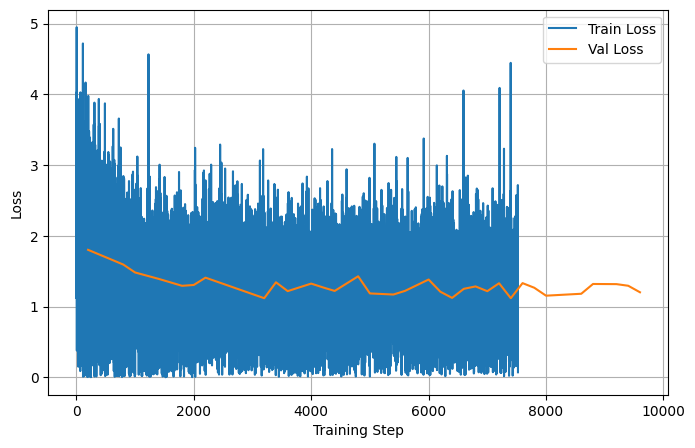

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

# Train
plt.plot(range(len(train_losses)), train_losses, label="Train Loss")

# Validation (step 기반)
plt.plot(val_steps, val_losses, label="Val Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

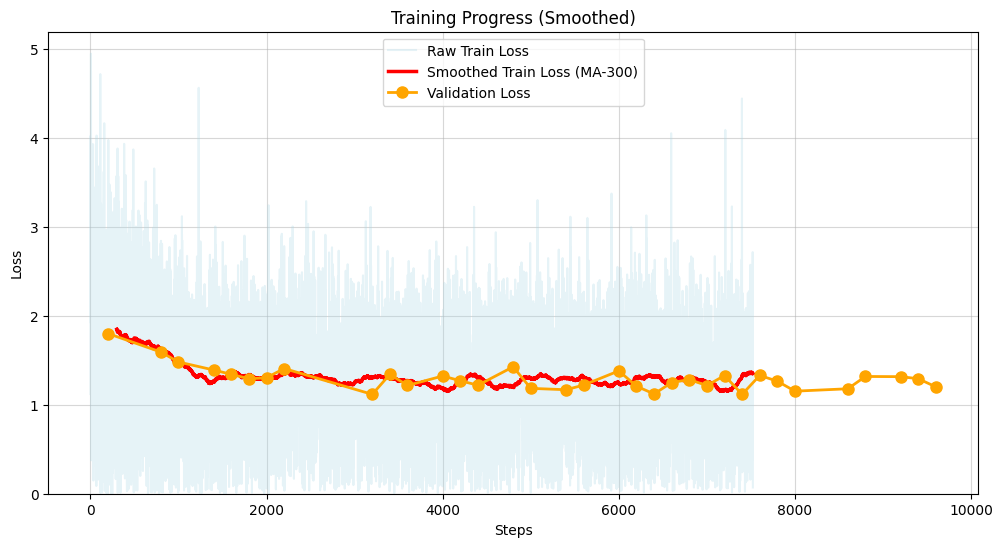

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. 데이터 스무딩 함수 (윈도우 크기 대폭 증가)
# ---------------------------------------------------------
def smooth_curve(points, window_size=300): # 50 -> 300으로 변경 (더 부드럽게)
    if len(points) < window_size:
        return points
    # 컨볼루션을 이용한 이동 평균 계산
    box = np.ones(window_size) / window_size
    return np.convolve(points, box, mode='valid')

# 스무딩 적용
smooth_train_losses = smooth_curve(train_losses, window_size=300)

# ---------------------------------------------------------
# 2. 그래프 그리기
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# (1) 원본 Train Loss (너무 지저분하면 투명도를 낮추거나 주석 처리하세요)
plt.plot(train_losses, label='Raw Train Loss', color='lightblue', alpha=0.3)

# (2) 스무딩된 Train Loss (진한 빨간색)
# x축 보정을 위해 앞부분(window_size만큼)을 띄우고 그립니다
plt.plot(
    range(300-1, len(train_losses)), 
    smooth_train_losses, 
    label='Smoothed Train Loss (MA-300)', 
    color='red', 
    linewidth=2.5
)

# (3) Validation Loss (점)
if len(val_steps) > 0:
    plt.plot(val_steps, val_losses, label='Validation Loss', color='orange', marker='o', linewidth=2, markersize=8)

plt.title('Training Progress (Smoothed)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.5)
plt.ylim(bottom=0) # 0부터 시작하도록 고정 (선택사항)
plt.show()

In [21]:
import os

# 저장할 폴더 이름 설정
save_directory = "./fine_tuned_msa_lora"

# 폴더가 없으면 생성
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

# ---------------------------------------------------------
# 모델 저장 (LoRA 어댑터만 저장됨)
# ---------------------------------------------------------
print(f"Saving LoRA adapters to {save_directory}...")
lora_model.save_pretrained(save_directory)

print("✅ Model saved successfully!")
print(f"- Adapter config: {os.path.join(save_directory, 'adapter_config.json')}")
print(f"- Adapter weights: {os.path.join(save_directory, 'adapter_model.bin')}")

Saving LoRA adapters to ./fine_tuned_msa_lora...
✅ Model saved successfully!
- Adapter config: ./fine_tuned_msa_lora/adapter_config.json
- Adapter weights: ./fine_tuned_msa_lora/adapter_model.bin


In [1]:
# (참고용 코드) 나중에 불러올 때
from peft import PeftModel, PeftConfig
from MSA_Pairformer.model import MSAPairformer

# 1. 원본 베이스 모델 로드
base_model = MSAPairformer.from_pretrained(device=device)

# 2. 저장해둔 LoRA 어댑터 결합
model_to_load = PeftModel.from_pretrained(base_model, "./fine_tuned_msa_lora")

# 3. 평가 모드 전환
model_to_load.eval()
model_to_load.to(device)
print("LoRA model loaded!")

/home/mooolab/anaconda3/envs/pairformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'device' is not defined

In [1]:
from glob import glob
import random
from MSA_Pairformer.dataset import MSADataset, CollateAFBatch

# -----------------------------
# 0️⃣ Config
# -----------------------------
msa_root = "/mnt/mooo/yoosun/army/MSA_Pairformer/msa_BFVD"
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

max_seq_len = 128
max_depth = 32

# -----------------------------
# [추가] 랜덤 시드 고정 (이 코드가 꼭 필요합니다!)
# -----------------------------
SEED = 42  # 원하는 숫자로 설정 (보통 42를 많이 씀)
random.seed(SEED)
# 만약 numpy나 torch도 쓴다면 같이 고정하는 게 좋습니다.
# np.random.seed(SEED)
# torch.manual_seed(SEED)

# -----------------------------
# 1️⃣ 모든 .a3m 파일 수집
# -----------------------------
all_files = glob(f"{msa_root}/**/*.a3m", recursive=True)
# glob 결과는 운영체제마다 순서가 다를 수 있으므로, 한 번 정렬 후 섞는 게 가장 안전합니다.
all_files.sort() 

print(f"📁 Found total MSA files: {len(all_files)}")

# 랜덤 셔플 (위에서 seed를 고정했으므로 항상 똑같이 섞임)
random.shuffle(all_files)

# -----------------------------
# 2️⃣ Split
# -----------------------------
N = len(all_files)
train_files = all_files[:int(N * train_ratio)]
val_files   = all_files[int(N * train_ratio):int(N * (train_ratio + val_ratio))]
test_files  = all_files[int(N * (train_ratio + val_ratio)):]

print(f"✔ Train: {len(train_files)}")
print(f"✔ Val:   {len(val_files)}")
print(f"✔ Test:  {len(test_files)}")

📁 Found total MSA files: 351242
✔ Train: 280993
✔ Val:   35124
✔ Test:  35125


In [2]:
from torch.utils.data import DataLoader
from MSA_Pairformer.dataset import MSADataset, CollateAFBatch
import torch

# Dataset
train_dataset = MSADataset(
    msa_paths=train_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

val_dataset = MSADataset(
    msa_paths=val_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

test_dataset = MSADataset(
    msa_paths=test_files,
    max_seq_length=max_seq_len,
    max_msa_depth=max_depth,
)

# Collate
train_collate = CollateAFBatch(
    max_seq_length=max_seq_len,
    max_seq_depth=max_depth,
    min_seq_depth=4,
    mask_prob=0,
    mutate_pssm=False,
    query_only=True
)

val_collate = CollateAFBatch(
    max_seq_length=max_seq_len,
    max_seq_depth=max_depth,
    min_seq_depth=4,
    mask_prob=0,
    mutate_pssm=False,
    query_only=True
)

# Dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    collate_fn=train_collate,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    collate_fn=val_collate,
    pin_memory=True
)


In [4]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from peft import PeftModel
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import aa2tok_d, prepare_inputs_bf16
import os
os.environ["PATH"] = "/mnt/mooo/yoosun/army/MSA_Pairformer/hhsuite/bin:" + os.environ.get("PATH", "")


# ----------------------------------------------------------------
# 1. 평가 함수 정의 (샘플 제한 기능 추가)
# ----------------------------------------------------------------
MASK_TOKEN_IDX = aa2tok_d.get("<mask>", 23)

def evaluate_loss_limited(model, dataloader, device, max_samples=1000, desc="Evaluating"):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    # 진행 바 설정 (최대 max_samples 만큼)
    pbar = tqdm(dataloader, total=max_samples, desc=desc)
    
    with torch.no_grad():
        for i, batch in enumerate(pbar):
            # 제한된 샘플 수에 도달하면 중단
            if i >= max_samples:
                break
                
            if batch is None: continue

            # 1) 입력 준비
            msa_repr, mask, msa_mask, full_mask, pairwise_mask, _ = prepare_inputs_bf16(batch, device)
            labels = batch["msas"][:, 0, :].to(device).clone()

            # 2) 마스킹 (Train과 동일하게 15%)
            valid_token = (labels >= 0) & (labels < 26)
            rand_mask = (torch.rand_like(labels.float()) < 0.15) & valid_token
            
            # 마스크 없으면 강제 할당 (예외 처리)
            if rand_mask.sum() == 0:
                valid_indices = torch.where(valid_token)[1]
                if len(valid_indices) > 0:
                    rand_idx = valid_indices[torch.randint(0, len(valid_indices), (1,))]
                    rand_mask[:, rand_idx] = True
            
            masked_positions = rand_mask

            # 3) 입력 데이터 구멍 뚫기
            msa_repr[:, 0, :, :][masked_positions] = 0.0
            msa_repr[:, 0, :, :][masked_positions, MASK_TOKEN_IDX] = 1.0

            # 4) 모델 Forward
            with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                out = model(
                    msa=msa_repr,
                    mask=mask,
                    msa_mask=msa_mask,
                    full_mask=full_mask,
                    pairwise_mask=pairwise_mask,
                    return_contacts=False,
                    query_only=True
                )
                
                logits = out["logits"][:, 0, :, :]
                pred = logits[masked_positions]
                true = labels[masked_positions]
                
                valid_label_mask = (true >= 0) & (true < logits.size(-1))
                pred = pred[valid_label_mask]
                true = true[valid_label_mask]

                if true.numel() > 0:
                    loss = F.cross_entropy(pred.float(), true.long())
                    total_loss += loss.item()
                    num_batches += 1
            
            # 실시간 평균 Loss 표시
            current_avg = total_loss / num_batches if num_batches > 0 else 0
            pbar.set_postfix({"Avg Loss": f"{current_avg:.4f}"})

    return total_loss / num_batches if num_batches > 0 else 0.0

# ----------------------------------------------------------------
# 2. 실행 및 비교
# ----------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LIMIT = 2000  # 평가할 샘플 수

# (1) Test DataLoader (셔플 True 권장: 랜덤하게 1000개 뽑기 위해)
# 하지만 두 모델 간 공정한 비교를 위해 고정된 순서(Shuffle=False)로 앞에서 1000개만 씁니다.
test_loader = DataLoader(
    test_dataset, 
    batch_size=1, 
    shuffle=False, 
    num_workers=2, 
    collate_fn=val_collate
)

print(f"📊 Fast Comparison (First {LIMIT} samples)...")

# --- [A] Base Model ---
print("\n1. Base Model Evaluating...")
base_model = MSAPairformer.from_pretrained(device=device)
base_model.to(torch.bfloat16)
base_model.eval()

loss_base = evaluate_loss_limited(base_model, test_loader, device, max_samples=LIMIT, desc="Base Model")

del base_model
torch.cuda.empty_cache()

# --- [B] Fine-tuned Model ---
print("\n2. Fine-tuned Model Evaluating...")
base_model_ft = MSAPairformer.from_pretrained(device=device)
ft_model_path = "./fine_tuned_msa_lora"
ft_model = PeftModel.from_pretrained(base_model_ft, ft_model_path)
ft_model.to(torch.bfloat16)
ft_model.eval()

loss_ft = evaluate_loss_limited(ft_model, test_loader, device, max_samples=LIMIT, desc="FT Model")

# ----------------------------------------------------------------
# 3. 최종 결과
# ----------------------------------------------------------------
print("\n" + "="*45)
print(f"📢 Result on {LIMIT} Test Samples")
print(f"="*45)
print(f"📉 Base Model Loss : {loss_base:.4f}")
print(f"📉 Finetuned Loss  : {loss_ft:.4f}")
print(f"-"*45)
improvement = loss_base - loss_ft
print(f"🚀 Improvement     : {improvement:+.4f} (Lower is better)")
print(f"="*45)

📊 Fast Comparison (First 2000 samples)...

1. Base Model Evaluating...


Base Model:   7%|▋         | 145/2000 [00:07<01:34, 19.67it/s, Avg Loss=1.3340]/home/mooolab/anaconda3/envs/pairformer/lib/python3.11/site-packages/Bio/SeqIO/FastaIO.py:202: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. This format allows for comments before the first sequence; line


2. Fine-tuned Model Evaluating...


FT Model:   7%|▋         | 145/2000 [00:07<01:34, 19.56it/s, Avg Loss=1.2674]/home/mooolab/anaconda3/envs/pairformer/lib/python3.11/site-packages/Bio/SeqIO/FastaIO.py:202: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. This format allows for comments before the first sequence; lines 


📢 Result on 2000 Test Samples
📉 Base Model Loss : 1.2912
📉 Finetuned Loss  : 1.2575
---------------------------------------------
🚀 Improvement     : +0.0338 (Lower is better)


=============================================
Result on 2000 Test Samples
=============================================
Base Model Loss : 1.2912
Finetuned Loss  : 1.2575
---------------------------------------------
Improvement     : +0.0338 
=============================================

In [4]:
# @title Setup mmseqs2 + hhsuite + MSA pairformer
import os
import re
import sys
import gc
import io
import json
import time
import pickle
import shutil
import hashlib
import tarfile
import tempfile
import warnings
import importlib
import subprocess
from pathlib import Path
from sys import version_info
from contextlib import redirect_stdout, redirect_stderr
from typing import List, Dict, Optional, Tuple, Union
# from google.colab import files


from peft import PeftModel, PeftConfig
from MSA_Pairformer.model import MSAPairformer
import requests
import torch
import numpy as np
import matplotlib.pyplot as plt

class ColabFoldPairedMSA:
    """Simple class to get paired MSAs from ColabFold with extended filtering and genomic distance support"""
    def __init__(self, host_url: str = "https://api.colabfold.com",
                 cache_dir: Optional[str] = None):
        self.host_url = host_url
        self.job_id = None
        self.parsed_entries = None  # List of parsed entries with metadata

        # Set up cache directory
        if cache_dir is None:
            self.cache_dir = Path.home() / ".colabfold_cache"
        else:
            self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)

        print(f"Cache directory: {self.cache_dir}")

        # Initialize UniProt converter
        self._init_uniprot_converter()

    def _init_uniprot_converter(self):
        """Initialize UniProt ID to number conversion tables"""
        from string import ascii_uppercase

        # Initialize encoding tables
        self.pa = {a: 0 for a in ascii_uppercase}
        for a in ["O", "P", "Q"]:
            self.pa[a] = 1

        self.ma = [[{} for k in range(6)], [{} for k in range(6)]]

        # Fill encoding tables
        for n, t in enumerate(range(10)):
            for i in [0, 1]:
                for j in [0, 4]:
                    self.ma[i][j][str(t)] = n

        for n, t in enumerate(list(ascii_uppercase) + list(range(10))):
            for i in [0, 1]:
                for j in [1, 2]:
                    self.ma[i][j][str(t)] = n
            self.ma[1][3][str(t)] = n

        for n, t in enumerate(ascii_uppercase):
            self.ma[0][3][str(t)] = n
            for i in [0, 1]:
                self.ma[i][5][str(t)] = n

        self.upi_encoding = {}
        hex_chars = list(range(10)) + ['A', 'B', 'C', 'D', 'E', 'F']
        for n, char in enumerate(hex_chars):
            self.upi_encoding[str(char)] = n

    def _extract_uniprot_id(self, header: str) -> str:
        """Extract UniProt ID from header."""
        pos = header.find("UniRef")
        if pos == -1:
            return ""

        start = header.find('_', pos)
        if start == -1:
            return ""
        start += 1

        end = start
        while end < len(header) and header[end] not in ' _\t':
            end += 1

        uid = header[start:end]

        # Validate - including UPI IDs
        if len(uid) >= 3 and uid[:3] == "UPI":
            return uid

        # Regular UniProt ID validation
        if len(uid) not in [6, 10]:
            return ""
        if not uid[0].isalpha():
            return ""

        return uid

    def _uniprot_to_number(self, uniprot_ids: List[str]) -> List[int]:
        """Convert UniProt IDs to numbers for distance calculation."""
        numbers = []
        for uni in uniprot_ids:
            if not uni or not uni[0].isalpha():
                numbers.append(0)
                continue

            # Handle UPI IDs
            if uni.startswith("UPI") and len(uni) == 13:
                hex_part = uni[3:]  # Remove "UPI" prefix
                num = 0
                tot = 1

                # Process hexadecimal characters in reverse order
                for u in reversed(hex_part):
                    if str(u) in self.upi_encoding:
                        num += self.upi_encoding[str(u)] * tot
                        tot *= 16  # Base 16 for hexadecimal
                    else:
                        # Invalid hex character, assign 0
                        num = 0
                        break
                # Add offset to distinguish UPI IDs from standard ones
                # Use a large offset to avoid collisions
                numbers.append(num + 10**15)
                continue

            p = self.pa.get(uni[0], 0)
            tot, num = 1, 0

            if len(uni) == 10:
                for n, u in enumerate(reversed(uni[-4:])):
                    if str(u) in self.ma[p][n]:
                        num += self.ma[p][n][str(u)] * tot
                        tot *= len(self.ma[p][n].keys())

            for n, u in enumerate(reversed(uni[:6])):
                if n < len(self.ma[p]) and str(u) in self.ma[p][n]:
                    num += self.ma[p][n][str(u)] * tot
                    tot *= len(self.ma[p][n].keys())

            numbers.append(num)

        return numbers

    def _calculate_genomic_distances(self, entry: Dict) -> List[int]:
        """Calculate sequential distances between adjacent chains."""
        distances = []
        nums = entry['uniprot_nums']

        for i in range(1, len(nums)):
            if nums[i-1] and nums[i]:  # Both must be valid numbers
                dist = abs(nums[i] - nums[i-1])
                distances.append(dist)
            else:
                distances.append(-1)  # Invalid distance

        return distances

    def _get_cache_key(self, sequences: List[str], genomic_distance: Optional[int],
                       prefix: Optional[str]) -> str:
        """Generate a unique cache key for the request"""
        # Always use genomic_distance=20 for caching to maximize reuse
        cache_genomic_distance = 20 if genomic_distance is not None else None

        # Create a deterministic string representation
        cache_data = {
            'sequences': sequences,
            'genomic_distance': cache_genomic_distance,
            'prefix': prefix,
            'host_url': self.host_url
        }
        cache_str = json.dumps(cache_data, sort_keys=True)

        # Generate hash
        cache_hash = hashlib.sha256(cache_str.encode()).hexdigest()[:16]

        # Create human-readable prefix
        seq_info = f"{len(sequences)}seq"
        if prefix:
            seq_info += f"_{prefix}"

        return f"{seq_info}_{cache_hash}"

    def _load_from_cache(self, cache_key: str) -> bool:
        """Try to load parsed entries from cache"""
        cache_file = self.cache_dir / f"{cache_key}.pkl"

        if cache_file.exists():
            try:
                with open(cache_file, 'rb') as f:
                    cache_data = pickle.load(f)

                self.parsed_entries = cache_data['parsed_entries']
                self.job_id = cache_data.get('job_id', f"cached_{cache_key}")

                print(f"Loaded from cache: {cache_key}")
                return True
            except Exception as e:
                print(f"Cache load failed: {e}")
                return False

        return False

    def _save_to_cache(self, cache_key: str):
        """Save parsed entries to cache"""
        cache_file = self.cache_dir / f"{cache_key}.pkl"

        try:
            cache_data = {
                'parsed_entries': self.parsed_entries,
                'job_id': self.job_id,
                'timestamp': time.time()
            }

            with open(cache_file, 'wb') as f:
                pickle.dump(cache_data, f)

            print(f"Saved to cache: {cache_key}")

            # Also save a human-readable info file
            info_file = self.cache_dir / f"{cache_key}_info.json"
            info_data = {
                'job_id': self.job_id,
                'num_entries': len(self.parsed_entries),
                'num_chains': len(self.parsed_entries[0]['sequences']) if self.parsed_entries else 0,
                'timestamp': time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(cache_data['timestamp']))
            }
            with open(info_file, 'w') as f:
                json.dump(info_data, f, indent=2)

        except Exception as e:
            print(f"Cache save failed: {e}")

    def clear_cache(self, older_than_days: Optional[int] = None):
        """Clear cache files, optionally only those older than specified days"""
        import glob

        cache_files = glob.glob(str(self.cache_dir / "*.pkl"))
        removed = 0

        for cache_file in cache_files:
            if older_than_days is not None:
                # Check age
                age_days = (time.time() - os.path.getmtime(cache_file)) / (24 * 3600)
                if age_days < older_than_days:
                    continue

            try:
                os.remove(cache_file)
                # Also remove info file if exists
                info_file = cache_file.replace('.pkl', '_info.json')
                if os.path.exists(info_file):
                    os.remove(info_file)
                removed += 1
            except:
                pass

        print(f"Removed {removed} cache files")

    def submit_or_load_from_cache(self,
                                  sequences: List[str],
                                  genomic_distance: Optional[int] = 20,
                                  prefix: Optional[str] = None,
                                  use_cache: bool = True) -> Tuple[str, bool]:
        """Submit sequences or load from cache if available

        Always uses genomic_distance=20 for caching to maximize reuse.

        Returns:
            Tuple of (job_id, from_cache) where from_cache indicates if data was loaded from cache
        """
        # Always use distance=20 for caching
        cache_genomic_distance = 20 if genomic_distance is not None else None

        # Generate cache key
        cache_key = self._get_cache_key(sequences, cache_genomic_distance, prefix)
        self._current_cache_key = cache_key

        # Try to load from cache
        if use_cache and self._load_from_cache(cache_key):
            return self.job_id, True

        # If not in cache, submit normally with distance=20
        self.submit(sequences, cache_genomic_distance, prefix)
        return self.job_id, False

    def submit(self,
               sequences: List[str],
               genomic_distance: Optional[int] = 20,
               prefix: Optional[str] = None) -> str:
        """Submit sequences and return job ID"""
        # Create query
        query = ""
        for i, seq in enumerate(sequences, start=101):
            if prefix:
                query += f">{prefix}_{i}\n{seq}\n"
            else:
                query += f">{i}\n{seq}\n"

        # Determine mode based on number of sequences
        if len(sequences) == 1:
            # Single sequence - use regular MSA mode
            mode = "env"
            endpoint = "ticket/msa"
        else:
            # Multiple sequences - use pairing mode
            if genomic_distance is None:
                mode = "paircomplete"
            else:
                mode = f"paircomplete-pairfilterprox_{genomic_distance}"
            endpoint = "ticket/pair"

        response = requests.post(
            f'{self.host_url}/{endpoint}',
            data={'q': query, 'mode': mode},
            timeout=30
        )

        if response.status_code != 200:
            raise Exception(f"Failed to submit: {response.text}")

        self.job_id = response.json()['id']
        print(f"Job submitted: {self.job_id} with mode: {mode}")
        return self.job_id

    def wait(self, check_interval: int = 5):
        """Wait for job completion"""
        while True:
            response = requests.get(f'{self.host_url}/ticket/{self.job_id}', timeout=30)
            status = response.json().get('status', 'UNKNOWN')
            print(f"Status: {status}")

            if status == "COMPLETE":
                break
            elif status == "ERROR":
                raise Exception("Job failed")
            time.sleep(check_interval)

    def download_and_parse(self, output_dir: str = "results"):
        """Download results and parse the MSA"""
        # Download
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        tar_path = os.path.join(output_dir, f"{self.job_id}.tar.gz")

        response = requests.get(f'{self.host_url}/result/download/{self.job_id}', timeout=60)
        with open(tar_path, 'wb') as f:
            f.write(response.content)

        # Extract
        with tarfile.open(tar_path) as tar:
            tar.extractall(output_dir)

        # Check if this is a paired MSA or single sequence MSA
        pair_a3m = os.path.join(output_dir, 'pair.a3m')
        if os.path.exists(pair_a3m):
            # Paired MSA
            self.parsed_entries = self._parse_paired_a3m(pair_a3m)
        else:
            # Single sequence - combine multiple MSA files
            self.parsed_entries = self._parse_single_msas(output_dir)

        # Save to cache if we have a cache key
        if hasattr(self, '_current_cache_key'):
            self._save_to_cache(self._current_cache_key)

    def _parse_msa_lines(self, lines: List[str]) -> List[Dict]:
        """Parse MSA lines into structured entries with UniProt ID extraction"""
        entries = []
        i = 0
        is_first = True

        while i < len(lines):
            line = lines[i].rstrip()

            if line.startswith('>'):
                header = line
                seq_lines = []
                i += 1

                # Collect sequence lines
                while i < len(lines) and not lines[i].startswith('>'):
                    if lines[i].strip():
                        seq_lines.append(lines[i].rstrip())
                    i += 1

                sequence = ''.join(seq_lines)

                # Parse header
                header_parts = header.split('\t')
                header_clean = header_parts[0].lstrip('>').replace('UniRef100_', '')

                # Extract UniProt ID
                uid = self._extract_uniprot_id(header)
                has_uniref = "UniRef" in header
                uniprot_num = 0

                if uid:
                    # Convert to number
                    uniprot_nums = self._uniprot_to_number([uid])
                    uniprot_num = uniprot_nums[0] if uniprot_nums else 0

                # For query sequence
                if is_first:
                    coverage = 1.0
                    identity = 1.0
                    evalue = 0.0
                    alnscore = float('inf')
                    is_first = False
                else:
                    # Extract metadata from header
                    coverage = None
                    identity = None
                    evalue = None
                    alnscore = None

                    if len(header_parts) >= 10:
                        try:
                            alnscore = float(header_parts[1])
                            identity = float(header_parts[2])
                            evalue = float(header_parts[3])
                            q_start = int(header_parts[4])
                            q_end = int(header_parts[5])
                            q_len = int(header_parts[6])
                            coverage = (q_end - q_start + 1) / q_len
                        except:
                            pass

                    # Fallback values
                    if coverage is None:
                        coverage = 0.0
                    if identity is None:
                        identity = 0.0
                    if evalue is None:
                        evalue = float('inf')
                    if alnscore is None:
                        alnscore = 0.0

                entries.append({
                    'header': header_clean,
                    'sequence': sequence,
                    'coverage': coverage,
                    'identity': identity,
                    'evalue': evalue,
                    'alnscore': alnscore,
                    'uid': uid,
                    'uniprot_num': uniprot_num,
                    'has_uniref': has_uniref
                })
            else:
                i += 1

        return entries

    def _parse_paired_a3m(self, a3m_path: str) -> List[Dict]:
        """Parse paired A3M file into list of entries with UniProt ID tracking"""
        # First, separate MSAs by chain ID
        raw_msas = {}
        update_M = True
        M = None

        with open(a3m_path, 'r') as f:
            for line in f:
                if "\x00" in line:
                    line = line.replace("\x00", "")
                    update_M = True

                if line.startswith(">") and update_M:
                    # Extract chain ID (101, 102, etc.)
                    M = int(line[1:].rstrip().split('_')[-1])
                    update_M = False
                    if M not in raw_msas:
                        raw_msas[M] = []

                if M is not None:
                    raw_msas[M].append(line.rstrip())

        # Parse each chain's MSA
        parsed_msas = {}
        for seq_id, lines in raw_msas.items():
            parsed_msas[seq_id] = self._parse_msa_lines(lines)

        # Get sorted chain IDs
        seq_ids = sorted(parsed_msas.keys())

        # IMPORTANT: All chains should have the same number of sequences when paired
        num_entries_per_chain = [len(parsed_msas[sid]) for sid in seq_ids]
        if len(set(num_entries_per_chain)) > 1:
            print(f"Warning: Chains have different numbers of sequences: {dict(zip(seq_ids, num_entries_per_chain))}")
            print("Taking minimum to preserve pairing")

        min_entries = min(num_entries_per_chain)

        # Stitch entries together - sequences at the same position are paired
        stitched_entries = []
        for i in range(min_entries):
            # Collect info from each chain at position i
            headers = []
            sequences = []
            coverages = []
            identities = []
            evalues = []
            alnscores = []
            uids = []
            uniprot_nums = []
            has_uniref = True  # Will be False if any chain doesn't have UniRef

            for sid in seq_ids:
                entry = parsed_msas[sid][i]
                headers.append(entry['header'])
                sequences.append(entry['sequence'])
                coverages.append(entry['coverage'])
                identities.append(entry['identity'])
                evalues.append(entry['evalue'])
                alnscores.append(entry['alnscore'])
                uids.append(entry['uid'])
                uniprot_nums.append(entry['uniprot_num'])
                has_uniref = has_uniref and entry['has_uniref']

            stitched_entries.append({
                'headers': headers,
                'sequences': sequences,
                'coverages': coverages,
                'identities': identities,
                'evalues': evalues,
                'alnscores': alnscores,
                'uids': uids,
                'uniprot_nums': uniprot_nums,
                'has_uniref': has_uniref,
                'is_query': (i == 0)
            })

        return stitched_entries

    def _parse_single_msas(self, output_dir: str) -> List[Dict]:
        """Parse and combine single sequence MSAs"""
        # MSA files to look for
        msa_files = ['uniref.a3m', 'bfd.mgnify30.metaeuk30.smag30.a3m']

        all_entries = []
        seen_sequences = set()

        for msa_file in msa_files:
            msa_path = os.path.join(output_dir, msa_file)
            if os.path.exists(msa_path):
                with open(msa_path, 'r') as f:
                    lines = f.readlines()

                entries = self._parse_msa_lines(lines)

                # Add non-duplicate entries
                for entry in entries:
                    if entry['sequence'] not in seen_sequences:
                        seen_sequences.add(entry['sequence'])
                        all_entries.append({
                            'headers': [entry['header']],
                            'sequences': [entry['sequence']],
                            'coverages': [entry['coverage']],
                            'identities': [entry['identity']],
                            'evalues': [entry['evalue']],
                            'alnscores': [entry['alnscore']],
                            'uids': [entry['uid']],
                            'uniprot_nums': [entry['uniprot_num']],
                            'has_uniref': entry['has_uniref'],
                            'is_query': len(all_entries) == 0
                        })

        return all_entries

    def save_msa(self,
                 output_file: str,
                 min_coverage: Optional[float] = None,
                 min_identity: Optional[float] = None,
                 max_evalue: Optional[float] = None,
                 min_alnscore: Optional[float] = None,
                 max_genomic_distance: Optional[int] = None) -> Tuple[int, List[Dict]]:
        """Save MSA with optional filtering including genomic distance

        Returns:
            Tuple of (number of sequences written, list of filtered entries)
        """
        if not self.parsed_entries:
            raise ValueError("No MSA loaded. Run download_and_parse first.")

        # Smart parsing: convert percentages to fractions
        if min_coverage is not None and min_coverage > 1:
            min_coverage = min_coverage / 100
        if min_identity is not None and min_identity > 1:
            min_identity = min_identity / 100

        sequences_written = 0
        sequences_filtered = 0
        filtered_entries = []  # Store entries that pass the filter

        num_chains = len(self.parsed_entries[0]['sequences']) if self.parsed_entries else 0

        with open(output_file, 'w') as f:
            for entry in self.parsed_entries:
                # Skip filtering for query sequence
                if not entry['is_query']:
                    # All chains must pass the filter
                    filter_reasons = []

                    if min_coverage and any(c < min_coverage for c in entry['coverages']):
                        filter_reasons.append(f"coverage < {min_coverage}")
                    if min_identity and any(i < min_identity for i in entry['identities']):
                        filter_reasons.append(f"identity < {min_identity}")
                    if max_evalue is not None and any(e > max_evalue for e in entry['evalues'] if e is not None):
                        filter_reasons.append(f"evalue > {max_evalue}")
                    if min_alnscore is not None and any(a < min_alnscore for a in entry['alnscores'] if a is not None):
                        filter_reasons.append(f"alnscore < {min_alnscore}")

                    # Genomic distance filtering
                    if max_genomic_distance is not None and entry['has_uniref']:
                        distances = self._calculate_genomic_distances(entry)

                        if num_chains == 2:
                            # Simple case: check single distance
                            if distances[0] != -1 and distances[0] > max_genomic_distance:
                                filter_reasons.append(f"genomic distance > {max_genomic_distance}")
                        else:
                            # For >2 chains: check if all distances exceed threshold
                            # (relaxed filtering - keep if ANY distance is within threshold)
                            valid_distances = [d for d in distances if d != -1]
                            if valid_distances and all(d > max_genomic_distance for d in valid_distances):
                                filter_reasons.append(f"all genomic distances > {max_genomic_distance}")

                    if filter_reasons:
                        sequences_filtered += 1
                        continue

                # Write entry with modified header
                if entry['is_query']:
                    # Query header format: query_len1_len2_len3
                    header = "query"
                    for seq in entry['sequences']:
                        header += f"_len{len(seq)}"
                else:
                    # Regular header format: UID1_UID2_UID3_dist1-2_dist2-3
                    # First write UIDs (or original headers if no UID)
                    header_parts = []
                    for i, uid in enumerate(entry['uids']):
                        if uid:
                            header_parts.append(uid)
                        else:
                            header_parts.append(entry['headers'][i])

                    header = '_'.join(header_parts)

                    # Add distances if we have valid UIDs
                    if entry['has_uniref'] and all(entry['uids']):
                        distances = self._calculate_genomic_distances(entry)
                        for dist in distances:
                            if dist != -1:
                                header += f"_{dist}"

                sequence = ''.join(entry['sequences']).replace('\x00','')
                f.write(f">{header}\n{sequence}\n")
                sequences_written += 1
                filtered_entries.append(entry)

        print(f"Saved {sequences_written} sequences to {output_file}")
        if sequences_filtered > 0:
            print(f"Filtered out {sequences_filtered} sequences")
        return sequences_written, filtered_entries

    def get_stats(self, entries: Optional[List[Dict]] = None) -> Dict:
        """Get statistics about the MSA

        Args:
            entries: Optional list of entries to calculate stats from.
                    If None, uses all parsed entries.
        """
        if entries is None:
            entries = self.parsed_entries

        if not entries:
            return {}

        num_chains = len(entries[0]['sequences']) if entries else 0

        stats = {
            'num_chains': num_chains,
            'num_entries': len(entries),
        }

        # Per-chain statistics
        for i in range(num_chains):
            coverages = [e['coverages'][i] for e in entries[1:]]  # Skip query
            identities = [e['identities'][i] for e in entries[1:]]
            evalues = [e['evalues'][i] for e in entries[1:] if e['evalues'][i] is not None]
            alnscores = [e['alnscores'][i] for e in entries[1:] if e['alnscores'][i] is not None]

            chain_id = i + 101
            stats[f'chain_{chain_id}'] = {
                'query_length': len(entries[0]['sequences'][i]) if entries else 0,
                'avg_coverage': sum(coverages) / len(coverages) if coverages else 0,
                'avg_identity': sum(identities) / len(identities) if identities else 0,
                'avg_evalue': sum(evalues) / len(evalues) if evalues else 0,
                'avg_alnscore': sum(alnscores) / len(alnscores) if alnscores else 0,
                'min_evalue': min(evalues) if evalues else None,
                'max_alnscore': max(alnscores) if alnscores else None,
            }

        return stats

def get_paired_msa(sequences: Union[str, List[str]],
                   output_file: str,
                   genomic_distance: Optional[int] = 20,
                   min_coverage: Optional[float] = None,
                   min_identity: Optional[float] = None,
                   max_evalue: Optional[float] = None,
                   min_alnscore: Optional[float] = None,
                   prefix: Optional[str] = None,
                   host_url: str = "https://api.colabfold.com",
                   cache_dir: Optional[str] = None,
                   use_cache: bool = True,
                   keep_temp: bool = False) -> str:
    """
    Simple wrapper to get paired MSA from ColabFold with extended filtering

    Args:
        sequences: List of protein sequences or a single string with ':' delimiter
        output_file: Path to save the stitched MSA
        genomic_distance: Genomic distance for pairing (default: 20, None for no filtering)
        min_coverage: Minimum coverage filter (0-1 or 0-100 for percentage)
        min_identity: Minimum identity filter (0-1 or 0-100 for percentage)
        max_evalue: Maximum e-value filter (e.g., 1e-5, 0.001)
        min_alnscore: Minimum alignment score filter
        prefix: Optional prefix for sequence IDs
        host_url: ColabFold API URL
        cache_dir: Directory for caching results (default: ~/.colabfold_cache)
        use_cache: Whether to use caching (default: True)
        keep_temp: If True, keep temporary files for debugging (default: False)

    Returns:
        Path to the output file
    """
    # Handle string input
    if isinstance(sequences, str):
        # Split by ':' and clean up
        sequences = [seq.strip() for seq in sequences.split(':') if seq.strip()]

    # Further cleanup of sequences
    cleaned_sequences = []
    for seq in sequences:
        # Remove whitespace and convert to uppercase
        seq = ''.join(seq.split()).upper()
        # Only add non-empty sequences
        if seq:
            cleaned_sequences.append(seq)

    if not cleaned_sequences:
        raise ValueError("No valid sequences provided")

    sequences = cleaned_sequences

    # Store user's requested genomic distance
    user_genomic_distance = genomic_distance

    # Always fetch with distance=20 for better caching
    fetch_genomic_distance = 20 if genomic_distance is not None else None

    # Create temp directory
    if keep_temp:
        # Create a permanent temp directory
        temp_dir = tempfile.mkdtemp(prefix="colabfold_")
        print(f"Temporary files will be kept in: {temp_dir}")
    else:
        # Use context manager for automatic cleanup
        temp_context = tempfile.TemporaryDirectory()
        temp_dir = temp_context.__enter__()

    try:
        # Create handler with cache support
        msa = ColabFoldPairedMSA(host_url, cache_dir)

        # Store cache key for later use - always use distance=20 for caching
        cache_key = msa._get_cache_key(sequences, fetch_genomic_distance, prefix)
        msa._current_cache_key = cache_key

        # Submit or load from cache
        job_id, from_cache = msa.submit_or_load_from_cache(sequences, fetch_genomic_distance, prefix, use_cache)

        # Only wait and download if it's a new job (not from cache)
        if not from_cache:
            msa.wait()
            # Download and parse
            msa.download_and_parse(temp_dir)

        # Save MSA to temporary file first with user's requested distance filtering
        temp_output = os.path.join(temp_dir, "temp_output.a3m")
        num_sequences, filtered_entries = msa.save_msa(
            temp_output,
            min_coverage,
            min_identity,
            max_evalue,
            min_alnscore,
            max_genomic_distance=user_genomic_distance
        )

        # Move to final location
        shutil.move(temp_output, output_file)

        print(f"\nMSA saved to: {output_file}")

        # Print stats BEFORE filtering
        stats_before = msa.get_stats()
        print(f"\n=== Statistics BEFORE filtering ===")
        print(f"Total entries: {stats_before['num_entries']}")
        for i in range(stats_before['num_chains']):
            chain_stats = stats_before[f'chain_{i + 101}']
            print(f"Chain {i + 101}: query_length={chain_stats['query_length']}, "
                  f"avg_coverage={chain_stats['avg_coverage']:.2f}, "
                  f"avg_identity={chain_stats['avg_identity']:.2f}"
                  )

        # Print stats AFTER filtering (if any filtering was applied)
        if any([min_coverage, min_identity, max_evalue is not None, min_alnscore is not None, user_genomic_distance != fetch_genomic_distance]):
            stats_after = msa.get_stats(filtered_entries)
            print(f"\n=== Statistics AFTER filtering ===")
            print(f"Total entries: {stats_after['num_entries']} (saved)")
            for i in range(stats_after['num_chains']):
                chain_stats = stats_after[f'chain_{i + 101}']
                print(f"Chain {i + 101}: query_length={chain_stats['query_length']}, "
                      f"avg_coverage={chain_stats['avg_coverage']:.2f}, "
                      f"avg_identity={chain_stats['avg_identity']:.2f}"
                      )

        if keep_temp:
            print(f"\nTemporary files kept in: {temp_dir}")
            print("Files:")
            for file in os.listdir(temp_dir):
                print(f"  - {file}")

    finally:
        # Clean up if not keeping temp files
        if not keep_temp:
            temp_context.__exit__(None, None, None)

    return output_file


def get_unique_jobname(base_jobname):
    """Get a unique jobname by incrementing if directory already exists."""
    if not os.path.exists(base_jobname):
        return base_jobname

    counter = 1
    while os.path.exists(f"{base_jobname}_{counter}"):
        counter += 1

    return f"{base_jobname}_{counter}"

def prepare_sequences(sequence, remove_duplicates = True):
    """
    Clean and prepare sequences from input string.

    Args:
        sequence: Raw sequence string, chains separated by ':'
        remove_duplicates: If True, removes duplicate sequences while preserving order

    Returns:
        Tuple of (cleaned sequences, chain break indices)
    """
    # Clean sequence
    sequence = sequence.upper()
    sequence = re.sub("[^A-Z:/()]", "", sequence)
    sequence = re.sub(r"\(", ":(", sequence)
    sequence = re.sub(r"\)", "):", sequence)
    sequence = re.sub(":+", ":", sequence)
    sequence = re.sub("/+", "/", sequence)
    sequence = re.sub("^[:/]+", "", sequence)
    sequence = re.sub("[:/]+$", "", sequence)

    # Split into individual sequences
    sequences = sequence.split(":")
    sequences = [seq for seq in sequences if seq]

    # Remove duplicates while preserving order
    if remove_duplicates and len(sequences) > 1:
        seen = set()
        unique_sequences = []

        for seq in sequences:
            if seq not in seen:
                seen.add(seq)
                unique_sequences.append(seq)

        if len(unique_sequences) < len(sequences):
            print(f"Note: Removed {len(sequences) - len(unique_sequences)} duplicate sequence(s)")

        sequences = unique_sequences

    # Calculate chain break indices for the final sequences
    chain_breaks = []
    position = 0
    for i, seq in enumerate(sequences[:-1]):  # All except last sequence
        position += len(seq)
        chain_breaks.append(position)

    return sequences, chain_breaks

#################################################################################################
def convert_to_numpy(obj):
    """
    Recursively convert PyTorch tensors to numpy arrays, handling BFloat16 and nested structures.
    """
    if isinstance(obj, torch.Tensor):
        # Convert BFloat16 to Float32 first, then to numpy
        if obj.dtype == torch.bfloat16:
            return obj.float().cpu().numpy()
        else:
            return obj.cpu().numpy()
    elif isinstance(obj, dict):
        # Recursively convert dictionary values
        return {key: convert_to_numpy(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        # Recursively convert list elements
        return [convert_to_numpy(item) for item in obj]
    elif isinstance(obj, tuple):
        # Recursively convert tuple elements
        return tuple(convert_to_numpy(item) for item in obj)
    else:
        # Return as-is for non-tensor types
        return obj

def clear_gpu_memory(keep_model=True):
    """
    Clear GPU memory while optionally keeping the model.
    """
    # Get all objects in memory
    for obj in gc.get_objects():
        try:
            if isinstance(obj, torch.Tensor):
                # Skip model parameters if we want to keep the model
                if keep_model and hasattr(obj, '_base') and obj._base is not None:
                    continue
                del obj
        except:
            pass

    # Multiple rounds of garbage collection
    for _ in range(3):
        gc.collect()

    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

#################################################################################################

def run_msa_analysis(
    msa_file,
    sequences,
    breaks=None,
    max_msa_depth=512,
    mode="contacts",  # "contacts", "conservation", or "jacobian"
    mutation_subset=None,  # For jacobian mode: which mutations to test
    device=None,
    show_progress=True,
    use_query_biasing=True,
    fix_weights=True
):
    """
    Unified function for all MSA Pairformer analyses.

    Args:
        msa_file: Path to MSA file
        sequences: List of protein sequences or a single string with ':' delimiter
        breaks: Chain break indices (optional - will be computed from sequences if not provided)
        max_msa_depth: Maximum MSA depth
        mode: Analysis mode:
            - "contacts": Returns contact map from contact head
            - "conservation": Returns (L, 20) matrix of p(aa) at each position
            - "jacobian": Categorical Jacobian with flexible mutation subset
        mutation_subset: For jacobian mode, which mutations to test:
            - None: all 20 amino acids (default)
            - ['F', 'D', 'V']: specific amino acids
            - [13, 3, 19]: amino acid indices (0-19)
        device: Device to run on (defaults to CUDA if available)
        show_progress: Whether to show progress bar (for conservation/jacobian modes)

    Returns:
        - If mode="contacts": contact matrix (L, L) or full results dict
        - If mode="conservation": (L, 20) matrix of amino acid probabilities
        - If mode="jacobian": (L, K, L, 20) where K = len(mutation_subset) or 20 if None
    """
    # Handle sequence input
    if isinstance(sequences, str):
        sequences = [seq.strip() for seq in sequences.split(':') if seq.strip()]

    # Compute total length and breaks if not provided
    total_length = sum(len(seq) for seq in sequences)
    if breaks is None and len(sequences) > 1:
        breaks = []
        position = 0
        for seq in sequences[:-1]:
            position += len(seq)
            breaks.append(position)
    elif breaks is None:
        breaks = []

    try:
        # Set device
        if device is None:
            device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        # Clear memory before starting
        clear_gpu_memory(keep_model=True)

        # Load and process MSA
        np.random.seed(42)
        msa_obj = MSA(
            msa_file_path=msa_file,
            max_seqs=max_msa_depth,
            max_length=total_length,
            max_tokens=1e12,
            diverse_select_method="hhfilter",
            hhfilter_kwargs={"binary": "hhfilter"}
        )

        # Store MSA depth
        msa_depth = msa_obj.n_diverse_seqs

        # Prepare MSA tensors
        msa_tokenized_t = msa_obj.diverse_tokenized_msa
        msa_onehot_t = torch.nn.functional.one_hot(msa_tokenized_t, num_classes=len(aa2tok_d)).unsqueeze(0).float().to(device)

        # Prepare masks
        mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(msa_obj.diverse_tokenized_msa.unsqueeze(0))
        mask = mask.to(device)
        msa_mask = msa_mask.to(device)
        full_mask = full_mask.to(device)
        pairwise_mask = pairwise_mask.to(device)

        # Get sequence length
        seq_length = msa_onehot_t.shape[2]

        # Set model to eval mode
        global_model.eval()

        # Configure query-biasing
        if use_query_biasing:
            global_model.turn_on_query_biasing()
        else:
            global_model.turn_off_query_biasing()

        # Initialize common model kwargs
        model_kwargs = {
            'mask': mask,
            'msa_mask': msa_mask,
            'full_mask': full_mask,
            'pairwise_mask': pairwise_mask,
            'complex_chain_break_indices': [breaks] if breaks else None
        }

        # Initialize results dictionary
        results= {}

        with torch.no_grad():
            # Step 1: Always run a forward pass for logits, contacts, and sequence weights
            with torch.amp.autocast(dtype=torch.bfloat16, device_type="cuda"):
                contacts_res = global_model(
                    msa=msa_onehot_t.to(torch.bfloat16),
                    return_seq_weights=True,
                    **model_kwargs
                )
            # Store all contact results
            contacts_numpy = convert_to_numpy(contacts_res)
            results.update({
                "predicted_cb_contacts": contacts_numpy["predicted_cb_contacts"][0],
                "predicted_confind_contacts": contacts_numpy["predicted_confind_contacts"][0],
                "seq_weights_list_d": contacts_numpy["seq_weights_list_d"],
                "total_length": total_length,
                "max_msa_depth": max_msa_depth,
                "msa_depth": msa_depth,
                "weight_scale": msa_onehot_t.shape[1]
            })

            # Step 2: Run conservation and/or categorical jacobian analyses if specified
            if mode in ["conservation", "jacobian", "all"]:
                # Turn off query biasing if using fixed sequence weights from initial forward pass
                if use_query_biasing and fix_weights:
                    global_model.turn_off_query_biasing()
                    model_kwargs['seq_weights_dict'] = contacts_res['seq_weights_list_d']
                # Set up forward function based on sequence weighting strategy
                def f(msa_input, return_probs=False):
                    with torch.amp.autocast(dtype=torch.bfloat16, device_type="cuda"):
                        res = global_model(
                            msa=msa_input.to(torch.bfloat16),
                            return_seq_weights=False,
                            return_contacts=False,
                            query_only=True,
                            **model_kwargs
                        )
                    logits = res['logits'][0, 0, :seq_length, :20].float()
                    if return_probs:
                        return torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()
                    else:
                      return logits.cpu().numpy()

                # Conservation analysis
                if mode in ["conservation", "all"]:
                    # Initialize conservation matrix
                    conservation = np.zeros((seq_length, 20))
                    # Mask each position and compute predicted profiles
                    for n in range(seq_length):
                        if show_progress:
                            print(f"\rConservation: {n+1}/{seq_length} ({100*(n+1)//seq_length}%)", end="", flush=True)
                        # Mask position
                        msa_h = msa_onehot_t.clone()
                        msa_h[0, 0, n, :] = 0
                        msa_h[0, 0, n, aa2tok_d["<mask>"]] = 1
                        # Compute amino acid probabilities
                        probs = f(msa_h, return_probs=True)
                        conservation[n] = probs[n]
                    if show_progress:
                        print()
                    results['conservation'] = conservation

                if mode in ["jacobian", "all"]:
                    # Get baseline logits
                    fx = f(msa_onehot_t, return_probs=False)
                    wt_sequence = msa_tokenized_t[0].cpu().numpy()

                    # Parse mutation subset
                    if mutation_subset is None:
                        mutation_indices = list(range(20))
                    else:
                        mutation_indices = []
                        for mut in mutation_subset:
                            if isinstance(mut, str):
                                assert mut.upper() in aa2tok_d, f"Invalid mutation: {mut}"
                                mutation_indices.append(aa2tok_d[mut.upper()])
                            else:
                                assert int(mut) <= 19, f"Invalid mutation index: {mut}"
                                mutation_indices.append(int(mut))

                    # Initialize jacobian tensor and iterate over positions and mutations
                    fx_h = np.zeros((seq_length, len(mutation_indices), seq_length, 20))
                    for n in range(seq_length):
                        if show_progress:
                            print(f"\rJacobian: {n+1}/{seq_length} ({100*(n+1)//seq_length}%)", end="", flush=True)
                        wt_aa = wt_sequence[n]
                        for idx, mutation_aa in enumerate(mutation_indices):
                            if mutation_aa == wt_aa and mutation_subset is None:
                                fx_h[n, idx] = fx.copy()
                            else:
                                msa_h = msa_onehot_t.clone()
                                msa_h[0, 0, n, :] = 0
                                msa_h[0, 0, n, mutation_aa] = 1
                                fx_h[n, idx] = f(msa_h, return_probs=False)
                    if show_progress:
                        print()
                    # Compute delta
                    results['jacobian'] = fx - fx_h

        # Clean up
        del msa_onehot_t, mask, msa_mask, full_mask, pairwise_mask, msa_tokenized_t, msa_obj
        clear_gpu_memory(keep_model=True)

        return results

    except Exception as e:
        print(f"Error in MSA analysis: {e}")
        clear_gpu_memory(keep_model=True)
        raise

#################################################################################################

# Also include the jac_to_con function from your code
def jac_to_con(jac, center=True, diag="remove", apc=True,
               symm_before=True, symm_after=False):
    """Convert Jacobian to contact map"""
    X = jac.copy()
    Lx, Ax, Ly, Ay = X.shape

    if symm_before:
        X = X + X.transpose(2, 3, 0, 1)

    if center:
        for i in range(4):
            if X.shape[i] > 1:
                X -= X.mean(i, keepdims=True)

    contacts = np.sqrt(np.square(X).sum((1, 3)))

    if symm_after:
        contacts = contacts + contacts.T

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    if diag == "normalize":
        contacts_diag = np.diag(contacts)
        contacts = contacts / np.sqrt(contacts_diag[:, None] * contacts_diag[None, :])

    if apc:
        ap = contacts.sum(0, keepdims=True) * contacts.sum(1, keepdims=True) / contacts.sum()
        contacts = contacts - ap

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    return contacts

#################################################################################################
import pandas as pd
import numpy as np
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.transform import linear_cmap
from bokeh.palettes import gray, viridis, RdBu

output_notebook()

class ContactAnalyzer:
    def __init__(self, contacts, sequences, breaks, title):
        self.sequences = sequences
        self.breaks = breaks if breaks else []
        self.contacts = contacts
        self._prepare_data()
        self.title = title

    def _prepare_data(self):
        """Create position mapping with chain info"""
        full_seq = ''.join(self.sequences)
        chain_starts = [0] + self.breaks
        chain_ends = self.breaks + [len(full_seq)]

        # Map each position to chain info
        self.pos_info = {}
        self.chain_info = {}
        for i, (start, end) in enumerate(zip(chain_starts, chain_ends)):
            chain = chr(65 + i)  # A, B, C...
            seq = self.sequences[i]
            for j in range(start, end):
                pos_in_chain = j - start + 1
                abs_pos = j + 1
                self.pos_info[abs_pos] = f"{chain}:{pos_in_chain}{seq[j - start]}"
                self.chain_info[abs_pos] = chain

    def get_table(self, min_score=None):
        """Get contact table for display"""
        data = []
        n = self.contacts.shape[0]

        for i in range(n):
            for j in range(i + 1, n):  # Upper triangle only
                if min_score is None or self.contacts[i, j] >= min_score:
                    chain_i = self.chain_info[i + 1]
                    chain_j = self.chain_info[j + 1]
                    interaction = 'intra' if chain_i == chain_j else 'inter'

                    data.append({
                        'Residue i': self.pos_info[i + 1],
                        'Residue j': self.pos_info[j + 1],
                        'Score': f"{self.contacts[i, j]:.3f}",
                        'Chain i': chain_i,
                        'Chain j': chain_j,
                        'Type': interaction
                    })

        df = pd.DataFrame(data)
        return df.sort_values('Score', ascending=False)

    def get_plot_data(self, threshold=None):
        """Get filtered contact data for plotting"""
        data = []
        n = self.contacts.shape[0]

        for i in range(n):
            for j in range(n):
                if threshold is None or self.contacts[i, j] >= threshold:
                    chain_i = self.chain_info[i + 1]
                    chain_j = self.chain_info[j + 1]

                    data.append({
                        'i': str(i + 1),
                        'j': str(j + 1),
                        'value': self.contacts[i, j],
                        'label_i': self.pos_info[i + 1],
                        'label_j': self.pos_info[j + 1],
                        'type': 'intra' if chain_i == chain_j else 'inter'
                    })

        return pd.DataFrame(data)

    def plot(self, threshold=None, size=800):
        """Create bokeh plot"""
        from bokeh.plotting import figure, show
        from bokeh.transform import linear_cmap
        from bokeh.palettes import gray

        df = self.get_plot_data(threshold)
        n = self.contacts.shape[0]

        p = figure(
            width=size, height=size,
            x_range=[str(i) for i in range(1, n + 1)],
            y_range=[str(i) for i in range(1, n + 1)][::-1],
            tools="hover,save",
            tooltips=[
                ("Residue i", "@label_i"),
                ("Residue j", "@label_j"),
                ("Score", "@value{0.000}"),
                ("Type", "@type")
            ],
            title=self.title
        )
        p.title.text_font_size = '16pt'

        p.rect(x="i", y="j", width=1, height=1, source=df,
               fill_color=linear_cmap('value', gray(256)[::-1],
                                      low=df.value.min(),
                                      high=df.value.max()
                                      ),
               line_color=None)

        # Add chain breaks
        for b in self.breaks:
            p.line([str(b + 1)] * 2, ['1', str(n)], color='red', width=2)
            p.line(['1', str(n)], [str(b + 1)] * 2, color='red', width=2)

        p.xaxis.visible = False
        p.yaxis.visible = False
        p.grid.visible = False

        show(p)
#################################################################################################

def _setup_tools():
  """Download and compile C++ tools."""

  # Install HHsuite
  hhsuite_path = "hhsuite"
  if not os.path.isdir(hhsuite_path):
      print("Installing HHsuite...")
      os.makedirs(hhsuite_path, exist_ok=True)
      url = "https://github.com/soedinglab/hh-suite/releases/download/v3.3.0/hhsuite-3.3.0-SSE2-Linux.tar.gz"
      os.system(f"curl -fsSL {url} | tar xz -C {hhsuite_path}/")

  os.environ['PATH'] += f":{hhsuite_path}/bin:{hhsuite_path}/scripts"


python_version = f"{version_info.major}.{version_info.minor}"

# this part might not be needed
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Suppress progress bars and warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", category=FutureWarning, message=".*torch.distributed.reduce_op.*")
warnings.filterwarnings("ignore", category=UserWarning, message=".*HF_TOKEN.*")

# Install MSA Pairformer (only if not already installed)
if not os.path.isdir("MSA_Pairformer"):
    print("Setting up MSA Pairformer...")

    # Capture output for git clone
    GIT_REPO = 'https://github.com/yoakiyama/MSA_Pairformer'
    TMP_DIR = "tmp"
    os.makedirs(TMP_DIR, exist_ok=True)

    result = subprocess.run(
        f"git clone {GIT_REPO}.git",
        shell=True,
        capture_output=True,
        text=True
    )

    # Capture pip install output
    with io.StringIO() as buf, redirect_stdout(buf), redirect_stderr(buf):
        subprocess.run(
            ["pip", "install", "-e", "MSA_Pairformer/", "--no-deps"],
            capture_output=True,
            text=True
        )
        subprocess.run(
            ["pip", "install", "biopython", "einx", "jaxtyping"],
            capture_output=True,
            text=True
        )

    importlib.invalidate_caches()
    # Add the package to Python path
    package_path = os.path.abspath("MSA_Pairformer")
    if package_path not in sys.path:
        sys.path.insert(0, package_path)

    print("✓ MSA Pairformer installed successfully")

# Import MSA Pairformer modules
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA, aa2tok_d, prepare_msa_masks

# Initialize device
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device_name = torch.cuda.get_device_name(device) if device.type == 'cuda' else 'CPU'
print(f"Using device: {device_name}")

# Load model ONCE and store globally
if 'global_model' not in globals():
    print("Loading MSA Pairformer model (this will only happen once)...")

    # Suppress HuggingFace warnings during model loading
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        # Optionally capture stdout/stderr if the model loading is still too verbose
        with io.StringIO() as buf, redirect_stderr(buf):
            global_model = MSAPairformer.from_pretrained(device=device).to(torch.bfloat16)

    print("✓ Model loaded successfully and cached for reuse!")
else:
    print("✓ Using cached model")

_setup_tools()

Loading BokehJS ...

Using device: NVIDIA GeForce RTX 4090
Loading MSA Pairformer model (this will only happen once)...
✓ Model loaded successfully and cached for reuse!


In [5]:
# --- [B] Fine-tuned Model ---
print("\n2. Fine-tuned Model Evaluating...")
base_model_ft = MSAPairformer.from_pretrained(device=device)
ft_model_path = "./fine_tuned_msa_lora"
ft_model = PeftModel.from_pretrained(base_model_ft, ft_model_path)
ft_model.to(torch.bfloat16)
ft_model.eval()


2. Fine-tuned Model Evaluating...


Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 162885.59it/s]


PeftModel(
  (base_model): LoraModel(
    (model): MSAPairformer(
      (relative_position_encoding): RelativePositionEncoding(
        (out_embedder): LinearNoBias(in_features=139, out_features=256, bias=False)
      )
      (token_bond_to_pairwise_feat): Sequential(
        (0): Rearrange('... -> ... 1')
        (1): LinearNoBias(in_features=1, out_features=256, bias=False)
      )
      (msa_init_proj): LinearNoBias(in_features=28, out_features=464, bias=False)
      (core_stack): CoreModule(
        (layers): ModuleList(
          (0-21): 22 x ModuleList(
            (0): MSAPairWeightedAveraging(
              (msa_to_values_and_gates): Sequential(
                (0): LayerNorm((464,), eps=1e-05, elementwise_affine=True)
                (1): lora.Linear(
                  (base_layer): LinearNoBias(in_features=464, out_features=512, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
          

In [6]:
#what is the next step-> DMS score framework

# DMS scoring에 사용할 모델 선택
model = ft_model          # <-- finetuned LoRA
# model = base_model_ft   # <-- base로 하고 싶으면 이걸로
model.eval()
ft_model = ft_model.to(device=device, dtype=torch.bfloat16)

from torch.nn.functional import one_hot
from torch.amp import autocast


from scipy.stats import spearmanr

from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.proteingym_utils import MSA_processing
from MSA_Pairformer.dataset import aa2tok_d, prepare_msa_masks
from MSA_Pairformer.proteingym_utils import process_msa, sample_msa, label_row, calc_weights_fast
from tqdm import tqdm

In [ ]:

dms_file = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/data/viral_dms_substitutions/"
msa_file = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/msa/"
save_path = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/results_Lora/mine/no_proteingym"


# 1             PESV_POLG_Tsuboyama
# 5                SARS2_MRPO_Flynn
# 11        SARS2_RBD_Starr_binding
# 12     SARS2_RBD_Starr_expression
# 13          DENV_POLG_Suphatrakul
# 14                 IAV_H1_HA_Doud
# 15                   IAV_H1_HA_Wu
# 16                    IAV_PB2_Soh
# 17                  IAV_H3_HA_Lee
# 19                 IAV_H3_NP_Doud
# 20                 IAV_H1_NP_Doud
# 21                   IAV_NA_Jiang
# 22                      IAV_PA_Wu
# 23                    IAV_RDRP_Li
# 25               AAV2_CAPSD_Sinai
# 37         CVB3_POLG_Mattenberger
# 38           BPP22_COAT_Tsuboyama
# 39            BPT7_RPOL_Tsuboyama
# 40          HIV1_BF520_ENV_Haddox
# 41    HIV1_HV1B9_ENV_DuenasDecamp
# 42          HIV1_BG505_ENV_Haddox
# 43           LAMBDA_HCP_Tsuboyama
# 44           BP434_RPC1_Tsuboyama

## no proteingym
# 0                   LASSA_GP_Carr
# 2        SARS2_PLPRO_Wu_abundance
# 3         SARS2_PLPRO_Wu_activity
# 4         SARS2_PRD0038_RBD_Starr
# 6                RmYN02_RBD_Starr
# 7                RsYN04_RBD_Starr
# 8          SARS2_XBB15_RBD_Taylor
# 9       SARS2_BA1_SPIKE_Dadonaite
# 10    SARS2_DELTA_SPIKE_Dadonaite
# 18            IAV_H5_HA_Dadonaite
# 24                 NIPAH_F_Larsen
# 26                CVB3_2A_Alvarez
# 27                CVB3_2B_Alvarez
# 28                CVB3_2C_Alvarez
# 29                CVB3_3A_Alvarez
# 30                CVB3_3B_Alvarez
# 31                CVB3_3C_Alvarez
# 32                CVB3_3D_Alvarez
# 33               CVB3_VP1_Alvarez
# 34               CVB3_VP3_Alvarez
# 35              EV_CAPSD_Bakhache
# 36                EV_REP_Bakhache



name ="SARS2_PLPRO_Wu_abundance"
# name = "SARS2_PRD0038_RBD_Starr"
msa_file = msa_file +name+"/PLpro_final_fixed.a3m"
dms_file = dms_file + name+"_dms.csv"

# Load MSA using ProteinGym methodology
nSeqs = 256
filter_msa = False
hhfilter_min_cov = 75
hhfilter_max_seq_id = 90
hhfilter_min_seq_id = 30
num_cpus = 2  # 
path_to_hhfilter = "hhfilter" # Replace with path to hhfilter binary if necessary

# Create weights filename
weights_filename = msa_file.replace('.a3m', '_weights.npy')

# Load and process MSA
print("Loading MSA data...")
processed_msa = MSA_processing(
    MSA_location=msa_file,
    use_weights=False,
    weights_location=weights_filename,
    num_cpus=num_cpus,
    theta=0.2,  # Sequence weighting hyperparameter
    preprocess_MSA=True,
    threshold_sequence_frac_gaps=0.5,
    threshold_focus_cols_frac_gaps=1.0,
    remove_sequences_with_indeterminate_AA_in_focus_cols=True,
    weights_calc_method="eve"
)

print(f"Focus sequence name: {processed_msa.focus_seq_name}")
print(f"Number of sequences: {processed_msa.num_sequences}")
print(f"Sequence length: {processed_msa.seq_len}")
print(f"Neff (effective number of sequences): {processed_msa.Neff}")

# Sample sequences from MSA
seed = 0
msa_sampling_strategy = "sequence-reweighting"  # Use sequence-reweighting for better sampling

data = [
    sample_msa(
        sampling_strategy=msa_sampling_strategy,
        filename=msa_file,
        nseq=nSeqs,
         # Use the processed MSA for sampling
        processed_msa=processed_msa,
        random_seed=seed,
        num_cpus=num_cpus
    )
]

print(f"Sampled {len(data[0])} sequences from MSA")


nTokenTypes = len(np.unique(list(aa2tok_d.values())))
seq_l = [data[0][i][1] for i in range(len(data[0]))]
seq_a = np.array([list(seq) for seq in seq_l])
offset_idx = 1 # Since DMS positions are 1-indexed, but MSA positions are 0-indexed
wt_seq = seq_l[0] # Wild-type sequence


print(f"seq_a shape: {seq_a.shape}")

# Prepare MSA input tensors
tokenized_msa_t = torch.from_numpy(np.vectorize(aa2tok_d.get)(seq_a))
mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(tokenized_msa_t.unsqueeze(0))
mask = mask.to(device)
msa_mask = msa_mask.to(device)
full_mask = full_mask.to(device)
pairwise_mask = pairwise_mask.to(device)




all_token_probs = []
for i in tqdm(range(tokenized_msa_t.size(1)), desc="Scoring masked-marginals"):
    tokenized_msa_masked_t = tokenized_msa_t.clone()
    tokenized_msa_masked_t[0, i] = aa2tok_d['<mask>']  # mask out first sequence
    with torch.no_grad():
        msa_masked_onehot_t = one_hot(tokenized_msa_masked_t, num_classes=nTokenTypes).bfloat16().unsqueeze(0).to(device)
        with autocast(dtype=torch.bfloat16, device_type="cuda"):
            token_probs = torch.log_softmax(
                model(
                    msa=msa_masked_onehot_t,
                    return_seq_weights=False,
                    return_contacts=False,
                    query_only=True,
                    mask=mask,
                    msa_mask=msa_mask,
                    full_mask=full_mask,
                    pairwise_mask=pairwise_mask
                )['logits'],
                dim=-1
            )
    all_token_probs.append(token_probs[:, 0, i].detach().cpu())  # vocab size
token_probs = torch.cat(all_token_probs, dim=0).unsqueeze(0)





# rho, pval = spearmanr(dms_df["MSA_Pairformer_Score"], dms_df["DMS_score"])
# print(f"Spearman's rho: {rho}, p-value: {pval}")
# f, ax = plt.subplots(figsize=(6, 6))
# ax.scatter(np.log(dms_df["DMS_score"]), dms_df["MSA_Pairformer_Score"], alpha=0.5)
# ax.set_xlabel("DMS score (log)", fontsize=14)
# ax.set_ylabel("MSA Pairformer score", fontsize=14)
# ax.set_title("MSA Pairformer Score vs DMS Score", size=16)
# ax.tick_params(labelsize=12)


save_folder = os.path.join(save_path, name)
os.makedirs(save_folder, exist_ok=True)  # 폴더 없으면 생성

save_file = os.path.join(save_folder, "dms_with_pairformer_score.csv")
# Load DMS data
dms_df = pd.read_csv(dms_file)
dms_positions = set(dms_df["mutant"].map(lambda x: re.findall(r'[A-Z](\d+)[A-Z]', x)).explode().astype(int).tolist())

dms_df.to_csv(save_file, index=False)
dms_df[f"MSA_Pairformer_Score"] = dms_df.apply(
    lambda row: label_row(
        row["mutant"], wt_seq, token_probs.detach().cpu(), aa2tok_d, offset_idx
    ),
    axis=1,
)
print(f"DMS file with Pairformer scores saved to: {save_file}")


Loading MSA data...
Number of sequences in MSA (before preprocessing): 8962
Calculating proportion of gaps
Proportion of sequences dropped due to fraction of gaps: 99.17%
Proportion of non-focus columns removed: 0.0%
Proportion of sequences dropped due to indeterminate AAs: 4.05%
Number of sequences after preprocessing: 71
Data Shape = (71, 316, 20)
Not weighting sequence data
Neff = 71.0
Number of sequences:  71
Focus sequence name: >Original_WT 315aa
Number of sequences: 71
Sequence length: 316
Neff (effective number of sequences): 71.0
Sampling sequences from MSA with strategy: sequence-reweighting
Check sum weights MSA: 0.9999999999999998
Sampled 256 sequences from MSA
seq_a shape: (256, 316)


Scoring masked-marginals: 100%|██████████| 316/316 [03:01<00:00,  1.74it/s]

DMS file with Pairformer scores saved to: /mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/results_Lora/mine/no_proteingym/SARS2_PLPRO_Wu_abundance/dms_with_pairformer_score.csv


In [28]:
# Display information about the sampled data
print(f"Number of sampled sequences: {len(data[0])}")
print(f"First sequence (wild-type): {data[0][0][0]}")
print(f"Wild-type sequence length: {len(data[0][0][1])}")
print(f"Sample of sequences:")
for i in range(min(3, len(data[0]))):
    print(f"  {i}: {data[0][i][0][:50]}... -> {data[0][i][1][:50]}...")
# Additional information about the processed data
print(f"Number of token types: {nTokenTypes}")
print(f"Wild-type sequence: {wt_seq[:50]}...")
print(f"Wild-type sequence length: {len(wt_seq)}")
print(f"Tokenized MSA shape: {tokenized_msa_t.shape}")
print(f"Mask shapes - mask: {mask.shape}, msa_mask: {msa_mask.shape}, full_mask: {full_mask.shape}, pairwise_mask: {pairwise_mask.shape}")


Number of sampled sequences: 256
First sequence (wild-type): >Original_WT 315aa
Wild-type sequence length: 316
Sample of sequences:
  0: >Original_WT 315aa... -> MEVRTIKVFTTVDNINLHTQVVDMSMTYGQQFGPTYLDGADVTKIKPHNS...
  1: >A0A088DIE1	1675	0.541	0.000E+00	0	1448	1449	0	144... -> MCSKGYELNQKTHFSVELPWIQIGENPIKPWSVTPAEALNTVYAAIAEGK...
  2: >P0C6W5	419	0.317	1.307E-114	0	1355	1449	0	1113	69... -> MEGVPDPPKLKSMVVTTLKWCDPFANPVTGWDIPIEEALEYAKQQLPEPQ...
Number of token types: 28
Wild-type sequence: MEVRTIKVFTTVDNINLHTQVVDMSMTYGQQFGPTYLDGADVTKIKPHNS...
Wild-type sequence length: 316
Tokenized MSA shape: torch.Size([256, 316])
Mask shapes - mask: torch.Size([1, 316]), msa_mask: torch.Size([1, 256]), full_mask: torch.Size([1, 256, 316]), pairwise_mask: torch.Size([1, 316, 316])


Spearman's rho: 0.011459918014803097, p-value: 0.40266217418879724


/home/mooolab/anaconda3/envs/pairformer/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


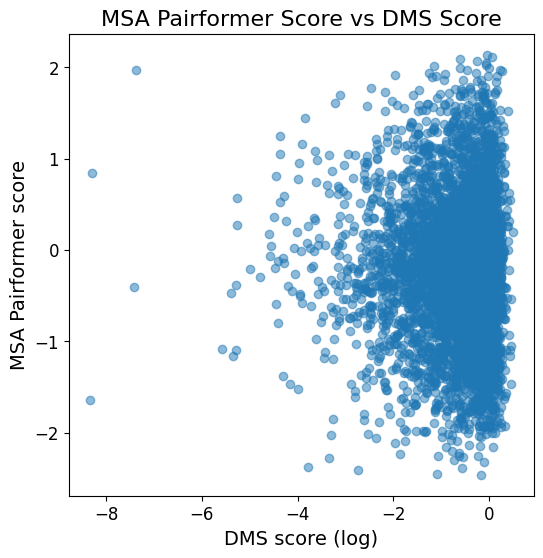

In [29]:
rho, pval = spearmanr(dms_df["MSA_Pairformer_Score"], dms_df["DMS_score"])
print(f"Spearman's rho: {rho}, p-value: {pval}")
f, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log(dms_df["DMS_score"]), dms_df["MSA_Pairformer_Score"], alpha=0.5)
ax.set_xlabel("DMS score (log)", fontsize=14)
ax.set_ylabel("MSA Pairformer score", fontsize=14)
ax.set_title("MSA Pairformer Score vs DMS Score", size=16)
ax.tick_params(labelsize=12)

Loading result data from: /mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/results_Lora/mine/no_proteingym/SARS2_PLPRO_Wu_activity/dms_with_pairformer_score.csv
----------------------------------------
Dataset: SARS2_PLPRO_Wu_activity
Spearman's rho: nan
p-value: nan
Data points: 5335
----------------------------------------
Saving plot image to: /mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/results_Lora/mine/no_proteingym/SARS2_PLPRO_Wu_activity/SARS2_PLPRO_Wu_activity_correlation_log.png


/home/mooolab/anaconda3/envs/pairformer/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


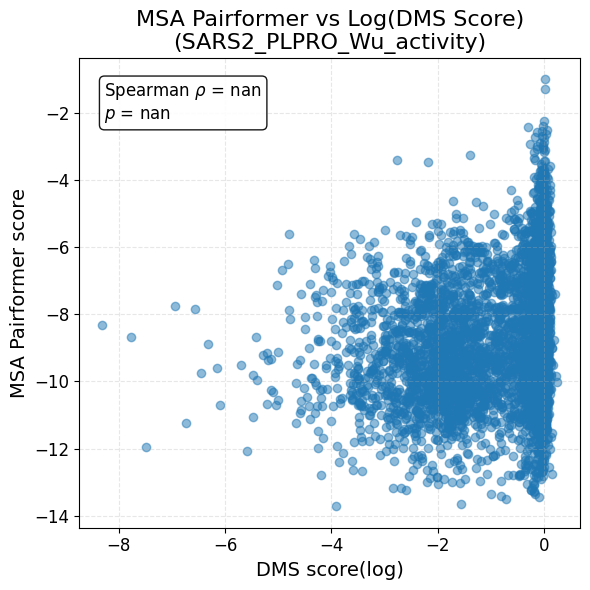

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, gaussian_kde

# -------------------------------------------------------------------------
# 1. 설정 (옵션 및 경로)
# -------------------------------------------------------------------------
SHOW_TRENDLINE = False   # 추세선 표시 여부
USE_DENSITY    = False   # 밀도(색깔) 표시 여부

dms_root_dir = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/data/viral_dms_substitutions/"
save_path_root = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/results_Lora/mine/no_proteingym"

name = "SARS2_PLPRO_Wu_activity"
result_file = os.path.join(save_path_root, name, "dms_with_pairformer_score.csv")

# -------------------------------------------------------------------------
# 2. 데이터 로드 및 전처리
# -------------------------------------------------------------------------
if os.path.exists(result_file):
    print(f"Loading result data from: {result_file}")
    dms_df = pd.read_csv(result_file)
    
    if "DMS_score" in dms_df.columns and "MSA_Pairformer_Score" in dms_df.columns:
        
        # 1. 결측치 제거
        dms_df = dms_df.dropna(subset=["DMS_score", "MSA_Pairformer_Score"])
        
        # 2. [중요] Log 변환을 위해 DMS score가 0보다 큰 값만 남김
        #    (0이나 음수는 log를 취할 수 없으므로 제외합니다)
        
        
        # 3. X축 로그 변환 (자연로그 np.log 또는 상용로그 np.log10 선택 가능)
        #    보통 분포를 볼 때는 로그를 취해야 예쁘게 펴집니다.
        x_final = dms_df["DMS_score"]
        y_final = dms_df["MSA_Pairformer_Score"]

        # 4. Spearman 상관계수 계산
        #    (순위 기반이라 x_final(로그값)을 쓰나 원본을 쓰나 양수 구간에선 결과가 같습니다)
        rho, pval = spearmanr(y_final, x_final) 
        
        print(f"-"*40)
        print(f"Dataset: {name}")
        print(f"Spearman's rho: {rho:.4f}")
        print(f"p-value: {pval:.4e}")
        print(f"Data points: {len(x_final)}")
        print(f"-"*40)

        # -------------------------------------------------------------------------
        # 3. 시각화 로직
        # -------------------------------------------------------------------------
        f, ax = plt.subplots(figsize=(6, 6))

        # (A) 밀도 옵션 처리
        if USE_DENSITY:
            try:
                xy = np.vstack([x_final, y_final])
                z = gaussian_kde(xy)(xy)
                idx = z.argsort()
                x_plot, y_plot, c_plot = x_final.iloc[idx], y_final.iloc[idx], z[idx]
                scatter_cmap = 'Spectral_r'
            except:
                x_plot, y_plot = x_final, y_final
                c_plot = 'royalblue'
                scatter_cmap = None
        else:
            x_plot, y_plot = x_final, y_final
            c_plot = 'royalblue'
            scatter_cmap = None

        # 산점도 그리기
        # scatter = ax.scatter(x_plot, y_plot, c=c_plot, cmap=scatter_cmap, 
        #                      s=20, alpha=0.5, edgecolors='none')
        scatter=ax.scatter(np.log(dms_df["DMS_score"]), dms_df["MSA_Pairformer_Score"], alpha=0.5)
        if USE_DENSITY and scatter_cmap is not None:
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.ax.set_ylabel('Density', rotation=270, labelpad=15)

        # (B) 추세선 옵션 처리
        if SHOW_TRENDLINE:
            slope, intercept = np.polyfit(x_final, y_final, 1)
            x_range = np.linspace(x_final.min(), x_final.max(), 100)
            y_pred = slope * x_range + intercept
            ax.plot(x_range, y_pred, color='black', linestyle='--', linewidth=1.5, label='Trend Line')
            ax.legend(loc='lower right')

        # 그래프 꾸미기
        ax.set_xlabel("DMS score(log)", fontsize=14)  # 라벨 수정
        ax.set_ylabel("MSA Pairformer score", fontsize=14)
        ax.set_title(f"MSA Pairformer vs Log(DMS Score)\n({name})", size=16)
        ax.tick_params(labelsize=12)
        
        stats_text = f"Spearman $\\rho$ = {rho:.3f}\n$p$ = {pval:.2e}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.tight_layout()

        # 저장
        save_dir = os.path.dirname(result_file)
        option_suffix = ""
        if USE_DENSITY: option_suffix += "_density"
        if SHOW_TRENDLINE: option_suffix += "_trend"
        
        image_filename = f"{name}_correlation_log{option_suffix}.png"
        image_save_path = os.path.join(save_dir, image_filename)

        print(f"Saving plot image to: {image_save_path}")
        plt.savefig(image_save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
    else:
        print("Error: CSV 파일에 필요한 컬럼이 없습니다.")
else:
    print(f"Error: 파일을 찾을 수 없습니다: {result_file}")



# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import spearmanr

# # -------------------------------------------------------------------------
# # 1. 설정
# # -------------------------------------------------------------------------
# dms_root_dir = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/data/viral_dms_substitutions/"
# save_path_root = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/results_Lora/mine/no_proteingym"

# name = "LASSA_GP_Carr"
# result_file = os.path.join(save_path_root, name, "dms_with_pairformer_score.csv")

# # -------------------------------------------------------------------------
# # 2. 데이터 로드 및 시각화 (제공해주신 코드 스타일 적용)
# # -------------------------------------------------------------------------
# if os.path.exists(result_file):
#     print(f"Loading result data from: {result_file}")
#     dms_df = pd.read_csv(result_file)
    
#     if "DMS_score" in dms_df.columns and "MSA_Pairformer_Score" in dms_df.columns:
        
#         # NaN 값 제거 (계산 오류 방지용)
#         dms_df = dms_df.dropna(subset=["DMS_score", "MSA_Pairformer_Score"])

#         # 1. Spearman 상관계수 계산 (원본 데이터 사용)
#         rho, pval = spearmanr(dms_df["MSA_Pairformer_Score"], dms_df["DMS_score"])
#         print(f"Spearman's rho: {rho}, p-value: {pval}")

#         # 2. 플 plotting (제공해주신 코드와 동일한 스타일)
#         f, ax = plt.subplots(figsize=(6, 6))
        
#         # np.log를 취할 때 0 이하인 값은 -inf 또는 NaN이 되어 그래프에서 표시되지 않습니다.
#         # (RuntimeWarning이 발생할 수 있으나 무시해도 됩니다)
#         ax.scatter(np.log(dms_df["DMS_score"]), dms_df["MSA_Pairformer_Score"], alpha=0.5)
        
#         ax.set_xlabel("DMS score (log)", fontsize=14)
#         ax.set_ylabel("MSA Pairformer score", fontsize=14)
#         ax.set_title(f"MSA Pairformer Score vs DMS Score\n({name})", size=16)
#         ax.tick_params(labelsize=12)

#         # 텍스트 추가 (선택 사항, 필요 없으면 주석 처리)
#         stats_text = f"Spearman $\\rho$ = {rho:.3f}\n$p$ = {pval:.2e}"
#         ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
#                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

#         # 3. 이미지 저장
#         save_dir = os.path.dirname(result_file)
#         image_filename = f"{name}_correlation_simple.png"
#         image_save_path = os.path.join(save_dir, image_filename)

#         print(f"Saving plot image to: {image_save_path}")
#         plt.savefig(image_save_path, dpi=300, bbox_inches='tight')
#         plt.show()

#     else:
#         print("Error: CSV 파일에 필요한 컬럼이 없습니다.")
# else:
#     print(f"Error: 파일을 찾을 수 없습니다: {result_file}")

In [1]:
## filtering training dataset for the zero shot 

# make_benchmark_fasta.py 로 저장 후 실행
import pandas as pd

# 경로 설정
csv_path = '/mnt/mooo/yoosun/army/MSA_Pairformer/viral_dms_reference.csv'
output_fasta = 'benchmark.fasta'

df = pd.read_csv(csv_path)

print(f"Reading CSV: {csv_path}")
with open(output_fasta, 'w') as f:
    for idx, row in df.iterrows():
        # ID는 나중에 알아보기 쉽게 만듦
        seq_id = row['DMS ID']
        sequence = row['Sequence'].strip()
        f.write(f">{seq_id}\n{sequence}\n")

print(f"Done! Saved to {output_fasta} ({len(df)} sequences)")

Reading CSV: /mnt/mooo/yoosun/army/MSA_Pairformer/viral_dms_reference.csv
Done! Saved to benchmark.fasta (45 sequences)


In [ ]:
# # 1. 겹치는 파일 개수 확인 (중복 제거)
# awk '{print $2}' overlaps.m8 | sort | uniq | wc -l

# # 2. 겹치는 파일명만 따로 저장 (삭제용 리스트)
# awk '{print $2}' overlaps.m8 | sort | uniq > files_to_delete.txt

In [1]:
import pandas as pd

# 컬럼 이름 정의
cols = ['Query', 'Target', 'Identity', 'Len', 'Mismatch', 'Gap', 
        'Q_start', 'Q_end', 'T_start', 'T_end', 'E_val', 'Score']

df = pd.read_csv('overlaps.m8', sep='\t', names=cols)

# 확인
print(df[['Query', 'Target', 'Identity']].head())

Empty DataFrame
Columns: [Query, Target, Identity]
Index: []


In [23]:
import numpy as np
from collections import Counter
import numpy as np
from Bio import SeqIO
from tqdm import tqdm

def calculate_neff(msa_path, threshold=0.8):
    # 1. 서열 로드
    seqs = []
    for record in SeqIO.parse(msa_path, "fasta"):
        seqs.append(str(record.seq))
    
    if not seqs: return 0
    
    # 길이 통일 (이미 정제된 파일이라면 이 과정은 빠르게 넘어갑니다)
    target_len = len(seqs[0])
    msa_matrix = np.array([list(s) for s in seqs], dtype='|S1')
    
    num_seqs = msa_matrix.shape[0]
    seq_len = msa_matrix.shape[1]
    
    print(f"📊 분석 중: {num_seqs} sequences, {seq_len} length")

    # 2. 가중치 계산 (Neff 산출)
    # 메모리 절약을 위해 배치를 나누어 계산합니다 (약 9000개 기준)
    batch_size = 500
    weights = np.zeros(num_seqs)
    
    # 바이너리 행렬로 변환하여 비교 가속
    msa_uint8 = msa_matrix.view(np.uint8)

    for i in tqdm(range(0, num_seqs, batch_size), desc="Calculating Neff"):
        end_i = min(i + batch_size, num_seqs)
        batch = msa_uint8[i:end_i]
        
        # Batch와 전체 MSA 간의 Identity 계산
        # (batch, 1, seq_len) == (1, num_seqs, seq_len) -> (batch, num_seqs)
        matches = np.sum(batch[:, np.newaxis, :] == msa_uint8[np.newaxis, :, :], axis=2)
        identity = matches / seq_len
        
        # Threshold(0.8) 이상인 서열 개수 카운트
        counts = np.sum(identity >= threshold, axis=1)
        weights[i:end_i] = 1.0 / counts

    neff_value = np.sum(weights)
    return neff_value

# === 실행부 ===
msa_file = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/msa/SARS2_PLPRO_Wu_abundance/PLpro_final_fixed.a3m"
neff = calculate_neff(msa_file)
print(f"\n✅ 최종 Neff: {neff:.2f}")
print(f"📈 가중치 적용 후 평균 서열 기여도: {(neff/53778)*100:.2f}%" if neff else "")
# === 실행 ===


dms_file = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/data/viral_dms_substitutions/"
msa_file = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/msa/"
save_path = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/results_Lora/mine/no_proteingym"


# 1             PESV_POLG_Tsuboyama
# 5                SARS2_MRPO_Flynn
# 11        SARS2_RBD_Starr_binding
# 12     SARS2_RBD_Starr_expression
# 13          DENV_POLG_Suphatrakul
# 14                 IAV_H1_HA_Doud
# 15                   IAV_H1_HA_Wu
# 16                    IAV_PB2_Soh
# 17                  IAV_H3_HA_Lee
# 19                 IAV_H3_NP_Doud
# 20                 IAV_H1_NP_Doud
# 21                   IAV_NA_Jiang
# 22                      IAV_PA_Wu
# 23                    IAV_RDRP_Li
# 25               AAV2_CAPSD_Sinai
# 37         CVB3_POLG_Mattenberger
# 38           BPP22_COAT_Tsuboyama
# 39            BPT7_RPOL_Tsuboyama
# 40          HIV1_BF520_ENV_Haddox
# 41    HIV1_HV1B9_ENV_DuenasDecamp
# 42          HIV1_BG505_ENV_Haddox
# 43           LAMBDA_HCP_Tsuboyama
# 44           BP434_RPC1_Tsuboyama

## no proteingym
# 0                   LASSA_GP_Carr
# 2        SARS2_PLPRO_Wu_abundance
# 3         SARS2_PLPRO_Wu_activity
# 4         SARS2_PRD0038_RBD_Starr
# 6                RmYN02_RBD_Starr
# 7                RsYN04_RBD_Starr
# 8          SARS2_XBB15_RBD_Taylor
# 9       SARS2_BA1_SPIKE_Dadonaite
# 10    SARS2_DELTA_SPIKE_Dadonaite
# 18            IAV_H5_HA_Dadonaite
# 24                 NIPAH_F_Larsen
# 26                CVB3_2A_Alvarez
# 27                CVB3_2B_Alvarez
# 28                CVB3_2C_Alvarez
# 29                CVB3_3A_Alvarez
# 30                CVB3_3B_Alvarez
# 31                CVB3_3C_Alvarez
# 32                CVB3_3D_Alvarez
# 33               CVB3_VP1_Alvarez
# 34               CVB3_VP3_Alvarez
# 35              EV_CAPSD_Bakhache
# 36                EV_REP_Bakhache



name ="LASSA_GP_Carr"

# name = "SARS2_PRD0038_RBD_Starr"
msa_file = msa_file +name+"/msa.a3m"
dms_file = dms_file + name+"_dms.csv"
msa_file = "/mnt/mooo/yoosun/army/MSA_Pairformer/SARS2_PLPRO_Wu_abundance/msa.a3m"
msa_file="/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/msa/SARS2_PLPRO_Wu_abundance/PLpro_final_fixed.a3m"
neff = calculate_neff(msa_file)
print(f"✅ Neff: {neff:.2f}")

📊 분석 중: 8963 sequences, 316 length


Calculating Neff: 100%|██████████| 18/18 [00:08<00:00,  2.03it/s]



✅ 최종 Neff: 30.87
📈 가중치 적용 후 평균 서열 기여도: 0.06%
📊 분석 중: 8963 sequences, 316 length


Calculating Neff: 100%|██████████| 18/18 [00:08<00:00,  2.04it/s]

✅ Neff: 30.87


In [22]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# 1. 설정값
target_wt = "MEVRTIKVFTTVDNINLHTQVVDMSMTYGQQFGPTYLDGADVTKIKPHNSHEGKTFYVLPNDDTLRVEAFEYYHTTDPSFLGRYMSALNHTKKWKYPQVNGLTSIKWADNNCYLATALLTLQQIELKFNPPALQDAYYRARAGEAANFCALILAYCNKTVGELGDVRETMSYLFQHANLDSCKRVLNVVCKTCGQQQTTLKGVEAVMYMGTLSYEQFKKGVQIPCTCGKQATKYLVQQESPFVMMSAPPAQYELKHGTFTCASEYTGNYQCGHYKHITSKETLYCIDGALLTKSSEYKGPITDVFYKENSYTTTIK"
target_len = 316
anchor = "MEVRT"

input_msa = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/msa/SARS2_PLPRO_Wu_abundance/A0A088DIE1.a3m"
output_msa = "/mnt/mooo/yoosun/army/MSA_Pairformer/priority_viruses/msa/SARS2_PLPRO_Wu_abundance/PLpro_final_fixed.a3m"

def bulletproof_slice_msa(input_file, output_file, wt_seq):
    # 쿼리 서열(WT)을 리스트에 먼저 넣습니다.
    final_records = [SeqRecord(Seq(wt_seq), id="Original_WT", description="315aa")]
    
    # 원본 파일 읽기
    records = list(SeqIO.parse(input_file, "fasta"))
    print(f"🔍 총 {len(records)}개의 서열 처리 시작...")

    for i, record in enumerate(records):
        # 1. 소문자 및 불필요 문자 제거 (오직 대문자와 -만 남김)
        raw_str = str(record.seq)
        clean_seq = "".join([c for c in raw_str if c.isupper() or c == "-"])
        
        # 2. 앵커를 기준으로 자르기
        if anchor in clean_seq:
            start_pos = clean_seq.find(anchor)
            sliced = clean_seq[start_pos:] # 일단 시작점부터 끝까지 가져옴
        else:
            sliced = clean_seq # 못 찾으면 전체 사용
            
        # 3. [핵심] 무조건 target_len을 만족시키는 매직 라인
        # 부족하면 '-'를 315개 붙인 뒤 앞에서부터 315개를 자릅니다.
        final_seq_str = (sliced + "-" * target_len)[:target_len]
        
        # 4. 결과 저장
        new_record = SeqRecord(Seq(final_seq_str), id=record.id, description=record.description)
        final_records.append(new_record)

    # 파일 쓰기
    SeqIO.write(final_records, output_file, "fasta")
    
    # 마지막 검증: 저장된 파일의 모든 서열 길이를 다시 체크
    check_records = list(SeqIO.parse(output_file, "fasta"))
    lengths = [len(r.seq) for r in check_records]
    
    if len(set(lengths)) == 1 and lengths[0] == target_len:
        print(f"✅ 성공! 모든 서열({len(check_records)}개)이 정확히 {target_len}자로 통일되었습니다.")
    else:
        from collections import Counter
        print(f"❌ 실패! 길이 분포 확인: {Counter(lengths)}")

# 실행
bulletproof_slice_msa(input_msa, output_msa, target_wt)

🔍 총 8962개의 서열 처리 시작...
✅ 성공! 모든 서열(8963개)이 정확히 316자로 통일되었습니다.
